In [1]:
# Standard Library Imports
import os
import sys
import time
import gc
import random
import traceback
import numpy as np
import pandas as pd
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set environment variables to force single-threading
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# Function to set global seed for reproducibility
def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    # If using TensorFlow or PyTorch, set their seeds as well

# Define a master seed for the entire script
MASTER_SEED = 42
set_global_seed(MASTER_SEED)

# Data Manipulation Libraries
import numpy as np
import pandas as pd

# Visualization Libraries
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

# Increase determinism for TensorFlow (CPU only)
if 'tensorflow' in sys.modules:
    import tensorflow as tf

    # Set TensorFlow seed for reproducibility
    tf.random.set_seed(MASTER_SEED)

    # Configure threads for deterministic operations
    tf.config.threading.set_inter_op_parallelism_threads(1)
    tf.config.threading.set_intra_op_parallelism_threads(1)

    # Enable determinism for ops (available in TF 2.9+)
    try:
        tf.config.experimental.enable_op_determinism()
    except:
        print("TensorFlow experimental determinism not available in this version")

    # Disable optimizations that may introduce non-determinism
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

# For scikit-learn
try:
    from sklearn.utils import check_random_state
    from sklearn.base import clone
    # Ensure scikit-learn uses the same seed
    os.environ['SKLEARN_SEED'] = str(MASTER_SEED)
except:
    pass

# Force sequential thread model for Numpy
os.environ['PYTHONHASHSEED'] = str(MASTER_SEED)
np.random.seed(MASTER_SEED)

In [2]:
# Directories and files adjusted for the new competition
DATA_DIR = os.getenv('DATA_DIR', './data/')
main_files = [
    "train_sequences.csv",
    "train_labels.csv",
    "validation_sequences.csv",
    "validation_labels.csv",
    "test_sequences.csv",
    "sample_submission.csv"
]

DEFAULT_THRESHOLD = 0.4  # Default threshold after analysis

def optimize_dataframe(df, inplace=False, category_threshold=DEFAULT_THRESHOLD):
    """
    Optimizes the DataFrame to save memory.
    """
    if category_threshold < 0 or category_threshold > 1:
        raise ValueError("category_threshold must be between 0 and 1.")

    if not inplace:
        df = df.copy()

    for col in df.columns:
        col_type = df[col].dtype
        if np.issubdtype(col_type, np.integer):
            c_min, c_max = df[col].min(), df[col].max()
            if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
        elif np.issubdtype(col_type, np.floating):
            if df[col].min() > np.finfo(np.float32).min and df[col].max() < np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
        if col_type == object:
            unique_vals = len(df[col].unique())
            if unique_vals / len(df) < category_threshold:
                df[col] = df[col].astype('category')

    return df

def load_main_data(chunksize=50000):
    """
    Loads the main files.
    """
    data = {}
    for file_name in main_files:
        file_path = os.path.join(DATA_DIR, file_name)
        if os.path.exists(file_path):
            chunks = pd.read_csv(file_path, on_bad_lines='skip', low_memory=False, chunksize=chunksize)
            dataframes = [optimize_dataframe(chunk, category_threshold=DEFAULT_THRESHOLD) for chunk in chunks]
            data[file_name] = pd.concat(dataframes, ignore_index=True)
        else:
            print(f"File {file_path} not found!")
    return data

def check_data_integrity(original_df, optimized_df):
    """
    Checks if the optimization did not alter the data.
    """
    try:
        pd.testing.assert_frame_equal(original_df, optimized_df, check_like=True)
        print("Integrity check passed: No changes in data after optimization.")
    except AssertionError as e:
        print(f"Data integrity check failed: {e}")

def check_duplicates(df):
    """
    Checks for duplicates in the DataFrame.
    """
    duplicates = df[df.duplicated(keep=False)]
    if not duplicates.empty:
        print(f"Warning: Duplicates found in the dataset. Number of duplicates: {duplicates.shape[0]}")
        return duplicates
    else:
        print("No duplicates found.")
    return None

def test_thresholds(df):
    """
    Tests different thresholds for DataFrame optimization.
    """
    thresholds = np.linspace(0.1, 0.9, 9)
    memory_usages = []
    for threshold in thresholds:
        optimized_df = optimize_dataframe(df.copy(), category_threshold=threshold)
        memory_usages.append(optimized_df.memory_usage(deep=True).sum() / 1024**2)
    return thresholds, memory_usages

def plot_memory_usage(thresholds, memory_usages):
    """
    Plots memory usage versus thresholds.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, memory_usages, marker='o', linestyle='-')
    plt.title("Memory Usage vs. Threshold")
    plt.xlabel("Threshold")
    plt.ylabel("Memory Usage (MB)")
    plt.grid(True)
    plt.show()

def analyze_sequence_data(df_sequences):
    """
    Analyzes RNA sequence data.
    """
    # Basic information
    print(f"Total sequences: {len(df_sequences)}")
    print(f"Available columns: {df_sequences.columns.tolist()}")

    # Sequence analysis
    if 'sequence' in df_sequences.columns:
        # Distribution of sequence lengths
        seq_lengths = df_sequences['sequence'].apply(len)
        print(f"\nSequence length statistics:")
        print(f"Minimum: {seq_lengths.min()}")
        print(f"Maximum: {seq_lengths.max()}")
        print(f"Average: {seq_lengths.mean():.2f}")

        # Nucleotide count
        nucleotides = ['A', 'C', 'G', 'U']
        nucleotide_counts = {n: df_sequences['sequence'].str.count(n).sum() for n in nucleotides}
        total_nucleotides = sum(nucleotide_counts.values())

        print("\nNucleotide distribution:")
        for n, count in nucleotide_counts.items():
            print(f"{n}: {count} ({count/total_nucleotides*100:.2f}%)")

    return df_sequences

def analyze_label_data(df_labels):
    """
    Analyzes 3D coordinate data (labels).
    """
    print(f"Total entries in labels: {len(df_labels)}")
    print(f"Available columns: {df_labels.columns.tolist()}")

    # Analysis of 3D coordinates if available
    coord_columns = [col for col in df_labels.columns if col.startswith(('x_', 'y_', 'z_'))]
    if coord_columns:
        print(f"\nCoordinate columns found: {len(coord_columns)}")

        # Basic statistics of coordinates
        for i in range(1, 6):  # For the 5 possible structures
            x_col = f'x_{i}'
            y_col = f'y_{i}'
            z_col = f'z_{i}'

            if x_col in df_labels.columns and y_col in df_labels.columns and z_col in df_labels.columns:
                print(f"\nStatistics for structure {i}:")
                print(f"X - Mean: {df_labels[x_col].mean():.2f}, Std: {df_labels[x_col].std():.2f}")
                print(f"Y - Mean: {df_labels[y_col].mean():.2f}, Std: {df_labels[y_col].std():.2f}")
                print(f"Z - Mean: {df_labels[z_col].mean():.2f}, Std: {df_labels[z_col].std():.2f}")

    return df_labels

def create_submission_template(test_df, sample_submission_df):
    """
    Creates a submission template based on test data.
    """
    # Check if sample_submission.csv is available
    if sample_submission_df is None:
        print("Sample submission file not found. Creating a new template.")

        # Create a new DataFrame for submission
        submission_df = pd.DataFrame()

        # Example code to fill the template (adjust as needed)
        ids = []
        resnames = []
        resids = []

        for _, row in test_df.iterrows():
            sequence = row['sequence']
            target_id = row['target_id']

            for i, nucleotide in enumerate(sequence, 1):
                ids.append(f"{target_id}_{i}")
                resnames.append(nucleotide)
                resids.append(i)

        submission_df['ID'] = ids
        submission_df['resname'] = resnames
        submission_df['resid'] = resids

        # Add coordinate columns (5 structures)
        for i in range(1, 6):
            submission_df[f'x_{i}'] = 0.0
            submission_df[f'y_{i}'] = 0.0
            submission_df[f'z_{i}'] = 0.0
    else:
        submission_df = sample_submission_df.copy()
        print("Submission template created based on the provided example.")

    return submission_df

def main():
    start_time = time.time()

    # Load main data
    print("Loading main data...")
    main_data = load_main_data()

    # Check which files were loaded
    print("\nLoaded files:")
    for file_name, df in main_data.items():
        print(f"- {file_name}: {df.shape if df is not None else 'Not found'}")

    # Analyze training sequence data
    if "train_sequences.csv" in main_data:
        print("\n===== Training Sequences Analysis =====")
        analyze_sequence_data(main_data["train_sequences.csv"])

    # Analyze training label data
    if "train_labels.csv" in main_data:
        print("\n===== Training Labels Analysis =====")
        analyze_label_data(main_data["train_labels.csv"])

    # Check for duplicates in training data
    if "train_sequences.csv" in main_data:
        print("\nChecking for duplicates in training sequences...")
        check_duplicates(main_data["train_sequences.csv"])

    # Create submission template
    if "test_sequences.csv" in main_data:
        print("\nCreating submission template...")
        submission_template = create_submission_template(
            main_data["test_sequences.csv"],
            main_data.get("sample_submission.csv")
        )
        print(f"Submission template shape: {submission_template.shape}")
        print(f"First rows of the submission template:")
        print(submission_template.head())

    # Calculate execution time
    end_time = time.time()
    print(f"\nRuntime: {end_time - start_time:.2f} seconds")

    return main_data

if __name__ == '__main__':
    main_data = main()

Loading main data...

Loaded files:
- train_sequences.csv: (844, 5)
- train_labels.csv: (137095, 6)
- validation_sequences.csv: (12, 5)
- validation_labels.csv: (2515, 123)
- test_sequences.csv: (12, 5)
- sample_submission.csv: (2515, 18)

===== Training Sequences Analysis =====
Total sequences: 844
Available columns: ['target_id', 'sequence', 'temporal_cutoff', 'description', 'all_sequences']

Sequence length statistics:
Minimum: 3
Maximum: 4298
Average: 162.43

Nucleotide distribution:
A: 32524 (23.72%)
C: 33937 (24.76%)
G: 41450 (30.24%)
U: 29178 (21.28%)

===== Training Labels Analysis =====
Total entries in labels: 137095
Available columns: ['ID', 'resname', 'resid', 'x_1', 'y_1', 'z_1']

Coordinate columns found: 3

Statistics for structure 1:
X - Mean: 80.45, Std: 147.42
Y - Mean: 84.04, Std: 114.93
Z - Mean: 98.61, Std: 119.41

Checking for duplicates in training sequences...
No duplicates found.

Creating submission template...
Submission template created based on the provided

In [3]:
# Updated main directory
dir_main = "./data"

# List all files and directories in the main directory
try:
    all_files = os.listdir(dir_main)
    print(f"All files and directories in '{dir_main}':")

    for file in all_files:
        # Check if it's a file or directory
        full_path = os.path.join(dir_main, file)
        type_desc = "directory" if os.path.isdir(full_path) else "file"
        size = os.path.getsize(full_path) / 1024  # Size in KB
        print(f" - {file} ({type_desc}, {size:.2f} KB)")

        # If it's a directory, list up to 5 files inside it
        if os.path.isdir(full_path):
            try:
                internal_files = os.listdir(full_path)[:5]  # Limit to 5 files
                if internal_files:
                    print(f"   First files in '{file}':")
                    for internal_file in internal_files:
                        print(f"    * {internal_file}")
                    if len(os.listdir(full_path)) > 5:
                        print(f"    * ... and {len(os.listdir(full_path)) - 5} more file(s)")
                else:
                    print(f"   '{file}' is empty")
            except Exception as e:
                print(f"   Error listing contents of '{file}': {e}")
except Exception as e:
    print(f"Error listing directory {dir_main}: {e}")

# Check the structure of the main CSV files
main_files = [
    "train_sequences.csv",
    "train_labels.csv",
    "validation_sequences.csv",
    "validation_labels.csv",
    "test_sequences.csv",
    "sample_submission.csv"
]
print("\nChecking main CSV files:")

for file in main_files:
    full_path = os.path.join(dir_main, file)
    if os.path.exists(full_path):
        # Get file size
        size_mb = os.path.getsize(full_path) / (1024 * 1024)  # Size in MB

        # Read the first lines to check the structure
        try:
            import pandas as pd
            df = pd.read_csv(full_path, nrows=1)
            print(f"\n{file} ({size_mb:.2f} MB):")
            print(f"Columns: {df.columns.tolist()}")
            print(f"Example:")
            print(df.head())
        except Exception as e:
            print(f"Error reading {file}: {e}")
    else:
        print(f"{file} not found.")

All files and directories in './data':
 - train_labels.csv (file, 9430.44 KB)
 - .DS_Store (file, 6.00 KB)
 - MSA (directory, 26.81 KB)
   First files in 'MSA':
    * 4A4U_A.MSA.fasta
    * 4V6W_BC.MSA.fasta
    * 8DC2_B.MSA.fasta
    * 3W1K_F.MSA.fasta
    * 1YSH_A.MSA.fasta
    * ... and 851 more file(s)
 - validation_sequences.csv (file, 9.76 KB)
 - train_sequences.v2.csv (file, 54343.46 KB)
 - train_labels.v2.csv (file, 261923.90 KB)
 - CASP16_predictions_RNA_R1242 (directory, 6.06 KB)
   First files in 'CASP16_predictions_RNA_R1242':
    * R1242TS094_2
    * R1242TS358_2
    * R1242TS052_4
    * R1242TS358_5
    * R1242TS094_5
    * ... and 187 more file(s)
 - train_sequences.csv (file, 2975.69 KB)
 - test_sequences.csv (file, 9.76 KB)
 - PDB_1991structures (directory, 0.16 KB)
   First files in 'PDB_1991structures':
    * batch_download.sh
    * Data Export Growth.csv
    * list_file.txt
 - sample_submission.csv (file, 184.51 KB)
 - validation_labels.csv (file, 2431.67 KB)

Check

In [4]:
# Updated main directory
dir_main = "./data"

def load_data():
    """
    Loads the main CSV files from the Stanford RNA 3D Folding competition.
    Returns a dictionary with DataFrames.
    """
    main_files = [
        "train_sequences.csv",
        "train_labels.csv",
        "validation_sequences.csv",
        "validation_labels.csv",
        "test_sequences.csv",
        "sample_submission.csv"
    ]

    data = {}
    for file_name in main_files:
        file_path = os.path.join(dir_main, file_name)
        if os.path.exists(file_path):
            try:
                data[file_name] = pd.read_csv(file_path)
                print(f"File {file_name} loaded successfully. Shape: {data[file_name].shape}")
            except Exception as e:
                print(f"Error loading {file_name}: {e}")
        else:
            print(f"File {file_name} not found.")
            data[file_name] = None

    return data

def compare_columns(main_data):
    """
    Compares columns between different DataFrames.
    """
    # List all available keys
    print("\nLoaded files:")
    print(list(main_data.keys()))

    # Compare columns between train_sequences.csv and test_sequences.csv
    if "train_sequences.csv" in main_data and "test_sequences.csv" in main_data:
        train_cols = set(main_data["train_sequences.csv"].columns)
        test_cols = set(main_data["test_sequences.csv"].columns)

        print("\nColumns in train_sequences.csv:")
        print(list(main_data["train_sequences.csv"].columns))

        print("\nUnique columns in train_sequences.csv (not present in test_sequences.csv):")
        print(train_cols - test_cols)

        print("\nUnique columns in test_sequences.csv (not present in train_sequences.csv):")
        print(test_cols - train_cols)

    # Compare columns between train_labels.csv and validation_labels.csv
    if "train_labels.csv" in main_data and "validation_labels.csv" in main_data:
        train_label_cols = set(main_data["train_labels.csv"].columns)
        val_label_cols = set(main_data["validation_labels.csv"].columns)

        print("\nColumns in train_labels.csv:")
        print(list(main_data["train_labels.csv"].columns))

        print("\nColumns in validation_labels.csv:")
        print(list(main_data["validation_labels.csv"].columns))

        print("\nUnique columns in validation_labels.csv (not present in train_labels.csv):")
        print(val_label_cols - train_label_cols)

    # Compare columns between validation_labels.csv and sample_submission.csv
    if "validation_labels.csv" in main_data and "sample_submission.csv" in main_data:
        val_label_cols = set(main_data["validation_labels.csv"].columns)
        sample_cols = set(main_data["sample_submission.csv"].columns)

        print("\nColumns in sample_submission.csv:")
        print(list(main_data["sample_submission.csv"].columns))

        print("\nUnique columns in validation_labels.csv (not present in sample_submission.csv):")
        print(val_label_cols - sample_cols)

        print("\nUnique columns in sample_submission.csv (not present in validation_labels.csv):")
        print(sample_cols - val_label_cols)

def analyze_structure_format(main_data):
    """
    Analyzes the format of 3D structures (coordinates).
    """
    if "validation_labels.csv" in main_data and main_data["validation_labels.csv"] is not None:
        df = main_data["validation_labels.csv"]

        # Find all coordinate columns (x_1, y_1, z_1, etc.)
        coord_cols = [col for col in df.columns if col.startswith(('x_', 'y_', 'z_'))]

        # Group by structure
        structures = {}
        for col in coord_cols:
            # Extract structure number (e.g., "x_1" -> 1)
            parts = col.split('_')
            if len(parts) == 2:
                struct_num = int(parts[1])
                coord_type = parts[0]

                if struct_num not in structures:
                    structures[struct_num] = []

                structures[struct_num].append(col)

        print("\nStructure of the labels file:")
        print(f"Total structures found: {len(structures)}")

        # Show details of the first structure
        if structures:
            first_struct = min(structures.keys())
            print(f"\nDetails of structure {first_struct}:")
            print(f"Columns: {sorted(structures[first_struct])}")

            # Check for missing values
            for col in structures[first_struct]:
                missing = df[col].isna().sum()
                total = len(df)
                print(f"{col}: {missing} missing values ({missing/total*100:.2f}%)")

            # Check the range of non-missing values for the first structure
            for col in structures[first_struct]:
                non_null = df[col][df[col] != -1.0e+18]  # Values that are not -1.0e+18
                if not non_null.empty:
                    print(f"{col} - Range: [{non_null.min():.3f}, {non_null.max():.3f}]")

def main():
    # Load the data
    main_data = load_data()

    # Compare columns between different files
    compare_columns(main_data)

    # Analyze the format of 3D structures
    analyze_structure_format(main_data)

    return main_data

if __name__ == '__main__':
    main_data = main()

File train_sequences.csv loaded successfully. Shape: (844, 5)
File train_labels.csv loaded successfully. Shape: (137095, 6)
File validation_sequences.csv loaded successfully. Shape: (12, 5)
File validation_labels.csv loaded successfully. Shape: (2515, 123)
File test_sequences.csv loaded successfully. Shape: (12, 5)
File sample_submission.csv loaded successfully. Shape: (2515, 18)

Loaded files:
['train_sequences.csv', 'train_labels.csv', 'validation_sequences.csv', 'validation_labels.csv', 'test_sequences.csv', 'sample_submission.csv']

Columns in train_sequences.csv:
['target_id', 'sequence', 'temporal_cutoff', 'description', 'all_sequences']

Unique columns in train_sequences.csv (not present in test_sequences.csv):
set()

Unique columns in test_sequences.csv (not present in train_sequences.csv):
set()

Columns in train_labels.csv:
['ID', 'resname', 'resid', 'x_1', 'y_1', 'z_1']

Columns in validation_labels.csv:
['ID', 'resname', 'resid', 'x_1', 'y_1', 'z_1', 'x_2', 'y_2', 'z_2', 'x

File train_sequences.csv loaded successfully. Shape: (844, 5)
File train_labels.csv loaded successfully. Shape: (137095, 6)
File validation_sequences.csv loaded successfully. Shape: (12, 5)
File validation_labels.csv loaded successfully. Shape: (2515, 123)
File test_sequences.csv loaded successfully. Shape: (12, 5)
File sample_submission.csv loaded successfully. Shape: (2515, 18)

Loaded files:
- train_sequences.csv: (844, 5)
- train_labels.csv: (137095, 6)
- validation_sequences.csv: (12, 5)
- validation_labels.csv: (2515, 123)
- test_sequences.csv: (12, 5)
- sample_submission.csv: (2515, 18)

===== Analysis of 3D Structures (validation_labels.csv) =====
There are 40 x_ columns in the DataFrame.
There are 40 y_ columns in the DataFrame.
There are 40 z_ columns in the DataFrame.

Columns without missing values: 123
Completely empty columns: 0
Number of x columns: 40
Number of y columns: 40
Number of z columns: 40

Structure 1:
  Special values: x=15 (0.60%), y=15 (0.60%), z=15 (0.60%)


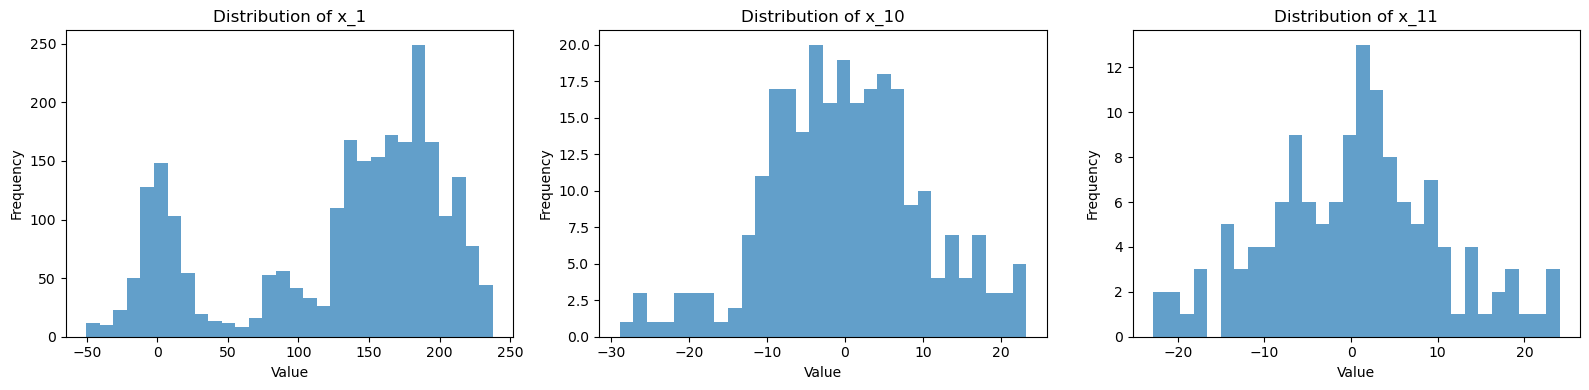


Distribution of Y coordinates:


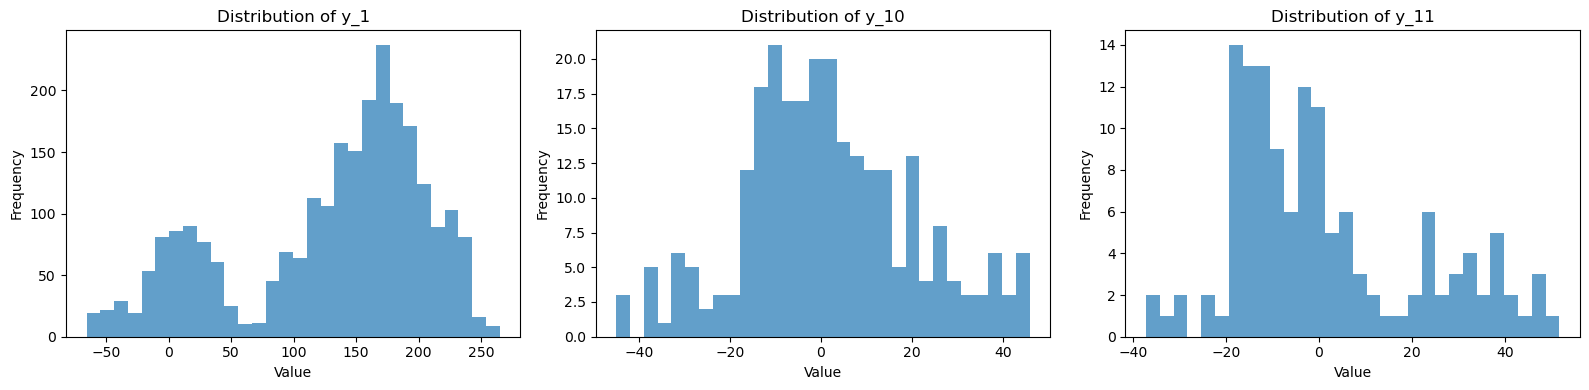


Distribution of Z coordinates:


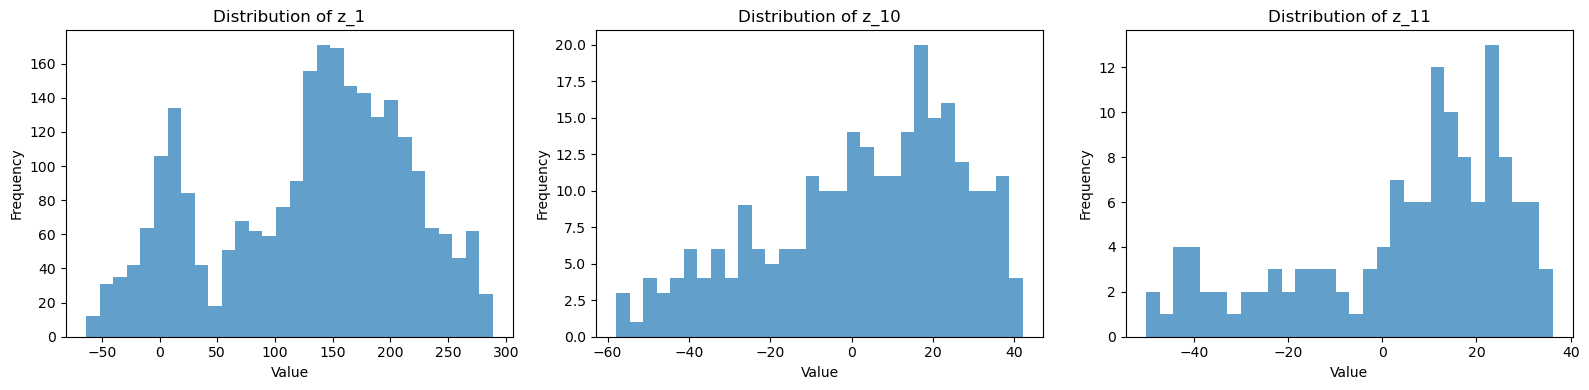


===== Analysis of Sequences (train_sequences.csv) =====

First few rows of the 'sequence' column:
0         GGGUGCUCAGUACGAGAGGAACCGCACCC
1    GGCGCAGUGGGCUAGCGCCACUCAAAAGGCCCAU
2              GGGACUGACGAUCACGCAGUCUAU
3                  GGGAUAACUUCGGUUGUCCC
4    GGCGACCCUGAUGAGGCCGAAAGGCCGAAACCGU
Name: sequence, dtype: object

Data type of the 'sequence' column:
object

Basic statistics of the 'sequence' column:
count                                                  844
unique                                                 784
top       UUUUUAAUUUCUACUCUUGUAGAUGUGAUAAGUGGAAUGCCAUGUGGA
freq                                                     5
Name: sequence, dtype: object

Sequence length statistics:
Minimum: 3
Maximum: 4298
Mean: 162.43
Median: 39.5

Nucleotide distribution:
-: 4 (0.00%)
A: 32524 (23.72%)
C: 33937 (24.75%)
G: 41450 (30.23%)
U: 29178 (21.28%)
X: 2 (0.00%)


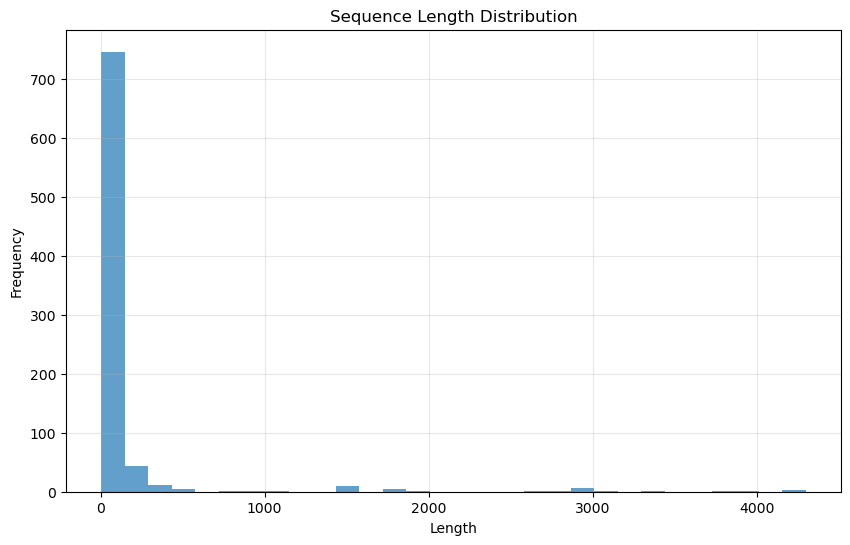

In [5]:
# Initialize seed to control randomness
np.random.seed(0)

# Directories and files adjusted for the new competition
DATA_DIR = os.getenv('DATA_DIR', './data')
main_files = [
   "train_sequences.csv",
   "train_labels.csv",
   "validation_sequences.csv",
   "validation_labels.csv",
   "test_sequences.csv",
   "sample_submission.csv"
]

DEFAULT_THRESHOLD = 0.4  # Default threshold after analysis

def optimize_dataframe(df, inplace=False, category_threshold=DEFAULT_THRESHOLD):
   """
   Optimizes the DataFrame to save memory.
   """
   if category_threshold < 0 or category_threshold > 1:
       raise ValueError("category_threshold must be between 0 and 1.")

   if not inplace:
       df = df.copy()

   for col in df.columns:
       col_type = df[col].dtype
       if np.issubdtype(col_type, np.integer):
           c_min, c_max = df[col].min(), df[col].max()
           if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
               df[col] = df[col].astype(np.int8)
           elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
               df[col] = df[col].astype(np.int16)
           elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
               df[col] = df[col].astype(np.int32)
       elif np.issubdtype(col_type, np.floating):
           # First check if it's not the special value -1.0e+18
           if df[col].min() > np.finfo(np.float32).min and df[col].max() < np.finfo(np.float32).max:
               df[col] = df[col].astype(np.float32)
       if col_type == object:
           unique_vals = len(df[col].unique())
           if unique_vals / len(df) < category_threshold:
               df[col] = df[col].astype('category')

   return df

def load_main_data(chunksize=50000):
   """
   Loads the main files.
   """
   data = {}
   for file_name in main_files:
       file_path = os.path.join(DATA_DIR, file_name)
       if os.path.exists(file_path):
           chunks = pd.read_csv(file_path, on_bad_lines='skip', low_memory=False, chunksize=chunksize)
           dataframes = [optimize_dataframe(chunk, category_threshold=DEFAULT_THRESHOLD) for chunk in chunks]
           data[file_name] = pd.concat(dataframes, ignore_index=True)
           print(f"File {file_name} loaded successfully. Shape: {data[file_name].shape}")
       else:
           print(f"File {file_path} not found!")
           data[file_name] = None
   return data

def filter_columns_by_prefix(df, prefix="x_"):
   """
   Filters and counts the number of columns in a DataFrame based on a provided prefix.

   :param df: DataFrame where filtering will be applied.
   :param prefix: Prefix to be used for filtering. Ex: "x_", "y_", "z_".
   :return: List of filtered columns.
   """
   filtered_columns = [col for col in df.columns if col.startswith(prefix)]
   return filtered_columns

def count_nucleotides(df, column_name='sequence'):
   """
   Counts the frequency of each nucleotide in a specific column of a DataFrame.

   :param df: DataFrame containing the sequences.
   :param column_name: Name of the column containing the sequences. Default is 'sequence'.
   :return: Counter object with the nucleotide counts.
   """
   from collections import Counter

   # Check if the column exists in the DataFrame
   if column_name not in df.columns:
       raise ValueError(f"Column '{column_name}' not found in DataFrame.")

   # Concatenate all sequences and count nucleotides
   all_sequences = ''.join(df[column_name].tolist())
   nucleotide_counts = Counter(all_sequences)

   return nucleotide_counts

def get_columns_without_missing_values(df):
   """
   Returns columns without any missing values in the DataFrame.

   :param df: DataFrame to be checked.
   :return: List of columns without missing values.
   """
   missing_values = df.isnull().sum()
   return missing_values[missing_values == 0].index.tolist()

def get_empty_columns(df):
   """
   Returns columns that are completely empty in the DataFrame.

   :param df: DataFrame to be checked.
   :return: List of empty columns.
   """
   missing_values = df.isnull().sum()
   return missing_values[missing_values == df.shape[0]].index.tolist()

def plot_coord_distributions(df_labels, prefix='x_', max_structures=5):
   """
   Plots the distribution of coordinates (x, y, or z) for up to max_structures structures.

   :param df_labels: DataFrame containing the coordinates.
   :param prefix: Prefix of columns to be plotted ('x_', 'y_', or 'z_').
   :param max_structures: Maximum number of structures to show.
   """
   # Find coordinate columns with the specified prefix
   coord_cols = filter_columns_by_prefix(df_labels, prefix)

   # Limit to the maximum number of structures
   coord_cols = sorted(coord_cols)[:max_structures]

   if not coord_cols:
       print(f"No column with prefix '{prefix}' found.")
       return

   # Set up the plot
   fig, axes = plt.subplots(1, len(coord_cols), figsize=(16, 4))
   if len(coord_cols) == 1:
       axes = [axes]  # Ensure axes is iterable even with a single subplot

   # Plot histograms for each column
   for i, col in enumerate(coord_cols):
       # Filter special values (-1.0e+18) if present
       values = df_labels[col]
       filtered_values = values[values > -1.0e+17]  # Cutoff value to filter -1.0e+18

       axes[i].hist(filtered_values, bins=30, alpha=0.7)
       axes[i].set_title(f'Distribution of {col}')
       axes[i].set_xlabel('Value')
       axes[i].set_ylabel('Frequency')

   plt.tight_layout()
   plt.show()

def analyze_3d_structure(df_labels):
   """
   Analyzes the 3D coordinates of RNA structures.

   :param df_labels: DataFrame containing 3D coordinates.
   """
   # Find all coordinate columns
   x_cols = filter_columns_by_prefix(df_labels, 'x_')
   y_cols = filter_columns_by_prefix(df_labels, 'y_')
   z_cols = filter_columns_by_prefix(df_labels, 'z_')

   print(f"Number of x columns: {len(x_cols)}")
   print(f"Number of y columns: {len(y_cols)}")
   print(f"Number of z columns: {len(z_cols)}")

   # Check for missing or special values in coordinates
   special_value = -1.0e+18  # Special value observed in the data

   for i, (x_col, y_col, z_col) in enumerate(zip(x_cols, y_cols, z_cols), 1):
       # Count missing or special values
       x_special = (df_labels[x_col] == special_value).sum()
       y_special = (df_labels[y_col] == special_value).sum()
       z_special = (df_labels[z_col] == special_value).sum()

       x_null = df_labels[x_col].isnull().sum()
       y_null = df_labels[y_col].isnull().sum()
       z_null = df_labels[z_col].isnull().sum()

       # Count how many complete structures exist (all x, y, z are neither special nor null)
       valid_structures = ((df_labels[x_col] != special_value) &
                          (df_labels[y_col] != special_value) &
                          (df_labels[z_col] != special_value) &
                          df_labels[x_col].notnull() &
                          df_labels[y_col].notnull() &
                          df_labels[z_col].notnull()).sum()

       total_rows = len(df_labels)

       print(f"\nStructure {i}:")
       print(f"  Special values: x={x_special} ({x_special/total_rows*100:.2f}%), y={y_special} ({y_special/total_rows*100:.2f}%), z={z_special} ({z_special/total_rows*100:.2f}%)")
       print(f"  Null values: x={x_null} ({x_null/total_rows*100:.2f}%), y={y_null} ({y_null/total_rows*100:.2f}%), z={z_null} ({z_null/total_rows*100:.2f}%)")
       print(f"  Complete structures: {valid_structures} ({valid_structures/total_rows*100:.2f}%)")

       # Limit analysis to the first 5 structures
       if i >= 5:
           print("\nAnalysis limited to the first 5 structures.")
           break

def analyze_sequences(df_sequences):
   """
   Analyzes RNA sequences.

   :param df_sequences: DataFrame containing the 'sequence' column.
   """
   # Basic statistics of the sequence column
   print("\nBasic statistics of the 'sequence' column:")
   print(df_sequences['sequence'].describe())

   # Sequence lengths
   seq_lengths = df_sequences['sequence'].apply(len)
   print("\nSequence length statistics:")
   print(f"Minimum: {seq_lengths.min()}")
   print(f"Maximum: {seq_lengths.max()}")
   print(f"Mean: {seq_lengths.mean():.2f}")
   print(f"Median: {seq_lengths.median()}")

   # Nucleotide counts
   nucleotide_counts = count_nucleotides(df_sequences)
   total_nucleotides = sum(nucleotide_counts.values())

   print("\nNucleotide distribution:")
   for nucleotide, count in sorted(nucleotide_counts.items()):
       print(f"{nucleotide}: {count} ({count/total_nucleotides*100:.2f}%)")

   # Plot length distribution
   plt.figure(figsize=(10, 6))
   plt.hist(seq_lengths, bins=30, alpha=0.7)
   plt.title('Sequence Length Distribution')
   plt.xlabel('Length')
   plt.ylabel('Frequency')
   plt.grid(True, alpha=0.3)
   plt.show()

def main():
   # Load main data
   main_data = load_main_data()

   # Check which files were loaded
   print("\nLoaded files:")
   for file_name, df in main_data.items():
       if df is not None:
           print(f"- {file_name}: {df.shape}")

   # Analyze 3D structures in validation_labels.csv
   if "validation_labels.csv" in main_data and main_data["validation_labels.csv"] is not None:
       print("\n===== Analysis of 3D Structures (validation_labels.csv) =====")
       df_labels = main_data["validation_labels.csv"]

       # Count coordinate columns
       x_cols = filter_columns_by_prefix(df_labels, 'x_')
       y_cols = filter_columns_by_prefix(df_labels, 'y_')
       z_cols = filter_columns_by_prefix(df_labels, 'z_')

       print(f"There are {len(x_cols)} x_ columns in the DataFrame.")
       print(f"There are {len(y_cols)} y_ columns in the DataFrame.")
       print(f"There are {len(z_cols)} z_ columns in the DataFrame.")

       # Identify columns without missing values
       columns_without_missing = get_columns_without_missing_values(df_labels)
       print(f"\nColumns without missing values: {len(columns_without_missing)}")

       # Identify completely empty columns
       empty_columns = get_empty_columns(df_labels)
       print(f"Completely empty columns: {len(empty_columns)}")

       # Analyze 3D coordinates in detail
       analyze_3d_structure(df_labels)

       # Plot distribution of x, y, z coordinates for the first structures
       print("\nDistribution of X coordinates:")
       plot_coord_distributions(df_labels, 'x_', max_structures=3)
       print("\nDistribution of Y coordinates:")
       plot_coord_distributions(df_labels, 'y_', max_structures=3)
       print("\nDistribution of Z coordinates:")
       plot_coord_distributions(df_labels, 'z_', max_structures=3)

   # Analyze sequences in train_sequences.csv
   if "train_sequences.csv" in main_data and main_data["train_sequences.csv"] is not None:
       print("\n===== Analysis of Sequences (train_sequences.csv) =====")
       df_sequences = main_data["train_sequences.csv"]

       # First few rows of the sequence column
       print("\nFirst few rows of the 'sequence' column:")
       print(df_sequences['sequence'].head())

       # Data type of the sequence column
       print("\nData type of the 'sequence' column:")
       print(df_sequences['sequence'].dtype)

       # Complete sequence analysis
       analyze_sequences(df_sequences)

   return main_data

if __name__ == '__main__':
   main_data = main()

In [6]:
# File paths
DATA_DIR = "./data"
OUTPUT_DIR = "./output"
# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

def load_data():
    """
    Loads the necessary data for the competition.
    """
    data = {}

    # Load sequences
    data['train_seq'] = pd.read_csv(os.path.join(DATA_DIR, "train_sequences.csv"))
    data['valid_seq'] = pd.read_csv(os.path.join(DATA_DIR, "validation_sequences.csv"))
    data['test_seq'] = pd.read_csv(os.path.join(DATA_DIR, "test_sequences.csv"))

    # Load structures (labels)
    data['train_labels'] = pd.read_csv(os.path.join(DATA_DIR, "train_labels.csv"))
    data['valid_labels'] = pd.read_csv(os.path.join(DATA_DIR, "validation_labels.csv"))

    # Load submission format
    data['sample_submission'] = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

    return data

def analyze_id_structure(data_dict):
    """
    Analyzes the ID structure in different files to understand the correct mapping.
    """
    # We'll analyze the specific formats for train and valid

    # 1. Analysis of training labels
    train_label_ids = data_dict['train_labels']['ID'].tolist()
    print(f"Total IDs in training labels: {len(train_label_ids)}")
    print(f"Number of unique IDs: {len(set(train_label_ids))}")

    # Try to understand the ID format in the labels file
    train_id_parts = {}
    for id_str in train_label_ids[:100]:  # Analyze the first 100
        parts = id_str.split('_')
        num_parts = len(parts)
        if num_parts not in train_id_parts:
            train_id_parts[num_parts] = []
        train_id_parts[num_parts].append(parts)

    print("\nID formats found in train_labels:")
    for num_parts, examples in train_id_parts.items():
        print(f"\nFormat with {num_parts} parts:")
        for i, parts in enumerate(examples[:3]):
            print(f"  Example {i+1}: {parts}")

    # 2. Analysis of training sequences
    train_seq_ids = data_dict['train_seq']['target_id'].tolist()
    print(f"\nTotal IDs in training sequences: {len(train_seq_ids)}")
    print(f"Number of unique IDs: {len(set(train_seq_ids))}")

    # Try to understand the ID format in the sequences file
    train_seq_id_parts = {}
    for id_str in train_seq_ids[:100]:  # Analyze the first 100
        parts = id_str.split('_')
        num_parts = len(parts)
        if num_parts not in train_seq_id_parts:
            train_seq_id_parts[num_parts] = []
        train_seq_id_parts[num_parts].append(parts)

    print("\nID formats found in train_sequences:")
    for num_parts, examples in train_seq_id_parts.items():
        print(f"\nFormat with {num_parts} parts:")
        for i, parts in enumerate(examples[:3]):
            print(f"  Example {i+1}: {parts}")

    # 3. Analysis of validation labels
    valid_label_ids = data_dict['valid_labels']['ID'].tolist()
    print(f"\nTotal IDs in validation labels: {len(valid_label_ids)}")
    print(f"Number of unique IDs: {len(set(valid_label_ids))}")

    # Count unique sequence IDs in validation labels
    valid_seq_ids_from_labels = set([id_str.split('_')[0] for id_str in valid_label_ids])
    print(f"Number of unique sequence IDs in validation labels: {len(valid_seq_ids_from_labels)}")
    print(f"Examples: {list(valid_seq_ids_from_labels)[:5]}")

    # 4. Analysis of validation sequences
    valid_seq_ids = data_dict['valid_seq']['target_id'].tolist()
    print(f"\nTotal IDs in validation sequences: {len(valid_seq_ids)}")
    print(f"Number of unique IDs: {len(set(valid_seq_ids))}")
    print(f"Examples: {valid_seq_ids[:5]}")

    # 5. Check correspondence between unique IDs
    overlap_valid = set(valid_seq_ids).intersection(valid_seq_ids_from_labels)
    print(f"\nCorrespondence between validation sequences and labels: {len(overlap_valid)} of {len(valid_seq_ids)}")

    # 6. Check how sequences and residues relate
    if len(overlap_valid) > 0:
        sample_id = list(overlap_valid)[0]
        sample_seq = data_dict['valid_seq'][data_dict['valid_seq']['target_id'] == sample_id]['sequence'].iloc[0]
        sample_labels = data_dict['valid_labels'][data_dict['valid_labels']['ID'].str.startswith(f"{sample_id}_")]

        print(f"\nAnalysis for sequence ID: {sample_id}")
        print(f"Sequence length: {len(sample_seq)}")
        print(f"Number of residues in labels: {len(sample_labels)}")

        # Check how residue numbers are related
        residue_numbers = sample_labels['resid'].sort_values().tolist()
        print(f"First residue numbers: {residue_numbers[:10]}")
        print(f"Last residue numbers: {residue_numbers[-10:]}")

    return train_id_parts, train_seq_id_parts, overlap_valid

def fix_train_mapping(train_seq_df, train_labels_df):
    """
    Identifies a correct mapping between train_sequences.csv and train_labels.csv
    using the ID format from the validation file as a reference.

    This is necessary because there's no obvious direct correspondence between the IDs.
    """
    # First, extract the prefix of the ID from labels (format: XX_Y_Z)
    train_labels_df['seq_id'] = train_labels_df['ID'].apply(lambda x: x.split('_')[0] + '_' + x.split('_')[1])

    # Check if this format corresponds to the format of sequence IDs
    seq_ids_set = set(train_seq_df['target_id'])
    label_seq_ids_set = set(train_labels_df['seq_id'])

    overlap = seq_ids_set.intersection(label_seq_ids_set)
    print(f"Overlap after format adjustment: {len(overlap)} of {len(seq_ids_set)}")

    if len(overlap) > 0:
        print(f"Examples of matching IDs: {list(overlap)[:5]}")
        return overlap

    # If it still doesn't work, we need to analyze the structure in more detail
    print("No matches found, checking other formats...")

    # Try other possible formats
    formats_to_try = [
        lambda x: x.split('_')[0],                             # Only first part
        lambda x: '_'.join(x.split('_')[:2]),                  # First two parts
        lambda x: x.split('_')[0] + '_' + x.split('_')[1][0],  # First part + first letter of second part
    ]

    for i, format_func in enumerate(formats_to_try):
        train_labels_df[f'seq_id_{i}'] = train_labels_df['ID'].apply(format_func)
        label_seq_ids_set = set(train_labels_df[f'seq_id_{i}'])
        overlap = seq_ids_set.intersection(label_seq_ids_set)
        print(f"Format {i}: Overlap = {len(overlap)} of {len(seq_ids_set)}")

        if len(overlap) > 0:
            print(f"Examples of matching IDs: {list(overlap)[:5]}")
            return overlap, f'seq_id_{i}'

    # If no match is found, create a mapping based on observed patterns
    print("No matches found using simple patterns.")
    print("Creating a manual mapping based on data structure...")

    # Group labels by first parts of ID
    train_labels_df['prefix'] = train_labels_df['ID'].apply(lambda x: x.split('_')[0])
    label_groups = train_labels_df.groupby('prefix')

    # For each sequence, find the best match based on number of residues
    mapping = {}
    for _, seq_row in train_seq_df.iterrows():
        seq_id = seq_row['target_id']
        seq_length = len(seq_row['sequence'])

        best_match = None
        best_diff = float('inf')

        for prefix, group in label_groups:
            residue_count = len(group)
            diff = abs(residue_count - seq_length)

            if diff < best_diff:
                best_diff = diff
                best_match = prefix

        # Consider a match only if the number of residues is close
        if best_diff <= 10:  # Tolerance of 10 residues
            mapping[seq_id] = best_match

    print(f"Manual mapping created with {len(mapping)} matches")
    return mapping

def create_mapping_valid(valid_seq_df, valid_labels_df):
    """
    Creates a mapping between validation sequences and their coordinates.

    In this case, the IDs already correspond directly (R1107 -> R1107_1, R1107_2, etc.)
    """
    # Check which ID format is used in the validation set
    valid_labels_df['seq_id'] = valid_labels_df['ID'].apply(lambda x: x.split('_')[0])

    # Check overlap
    seq_ids = set(valid_seq_df['target_id'])
    label_seq_ids = set(valid_labels_df['seq_id'])

    overlap = seq_ids.intersection(label_seq_ids)
    print(f"Correspondence for validation: {len(overlap)} of {len(seq_ids)}")

    mapping = {}
    for seq_id in overlap:
        # Get sequence
        seq = valid_seq_df[valid_seq_df['target_id'] == seq_id]['sequence'].iloc[0]

        # Get all residues for this sequence
        residues = valid_labels_df[valid_labels_df['seq_id'] == seq_id].sort_values('resid')

        # Extract coordinates for all structures
        num_structures = 1
        for col in residues.columns:
            if col.startswith('x_'):
                struct_num = int(col.split('_')[1])
                num_structures = max(num_structures, struct_num)

        # Initialize structures
        structures = []

        for struct_idx in range(1, num_structures + 1):
            coords = []
            has_valid_coords = False

            # Check if this structure has coordinates
            if f'x_{struct_idx}' in residues.columns:
                for _, row in residues.iterrows():
                    x = row[f'x_{struct_idx}']
                    y = row[f'y_{struct_idx}']
                    z = row[f'z_{struct_idx}']

                    # Check if they are valid values
                    if abs(x) < 1.0e+17 and abs(y) < 1.0e+17 and abs(z) < 1.0e+17:
                        coords.append([x, y, z])
                        has_valid_coords = True
                    else:
                        coords.append([np.nan, np.nan, np.nan])

            if has_valid_coords:
                structures.append(coords)

        # Add to mapping if there are valid structures
        if structures:
            mapping[seq_id] = {
                'sequence': seq,
                'structures': structures
            }

    print(f"Mapping created with {len(mapping)} valid sequences")
    return mapping

def create_processed_data(mapping, output_prefix):
    """
    Creates and saves processed data from the mapping.

    Parameters:
    mapping: Dictionary with the mapping of sequences to structures
    output_prefix: Prefix for output files ('train' or 'valid')

    Returns:
    X, y: Arrays for training
    """
    if not mapping:
        print(f"WARNING: No valid mapping for {output_prefix}")
        return None, None

    X_data = []
    y_data = []
    ids = []

    for seq_id, data in mapping.items():
        seq = data['sequence']
        structures = data['structures']

        # Skip if there are no structures
        if not structures:
            continue

        # Use the first valid structure
        structure = structures[0]

        # Check if the structure has valid coordinates for all residues
        if len(structure) != len(seq):
            print(f"WARNING: Difference between sequence length ({len(seq)}) and coordinates ({len(structure)}) for {seq_id}")
            # If needed, we could consider padding or truncation here
            continue

        # Create feature matrix (one-hot encoding)
        features = []
        for nucleotide in seq:
            if nucleotide == 'A':
                features.append([1, 0, 0, 0, 0])
            elif nucleotide == 'C':
                features.append([0, 1, 0, 0, 0])
            elif nucleotide == 'G':
                features.append([0, 0, 1, 0, 0])
            elif nucleotide == 'U':
                features.append([0, 0, 0, 1, 0])
            else:
                features.append([0, 0, 0, 0, 1])  # For unknown nucleotides

        X_data.append(np.array(features))
        y_data.append(np.array(structure))
        ids.append(seq_id)

    if not X_data:
        print(f"WARNING: No valid processed data for {output_prefix}")
        return None, None, []

    # Padding to ensure all sequences have the same length
    max_length = max(len(x) for x in X_data)
    X_padded = []
    y_padded = []

    for x, y in zip(X_data, y_data):
        if len(x) < max_length:
            x_pad = np.zeros((max_length, 5))
            x_pad[:len(x), :] = x

            y_pad = np.zeros((max_length, 3))
            y_pad[:len(y), :] = y

            X_padded.append(x_pad)
            y_padded.append(y_pad)
        else:
            X_padded.append(x)
            y_padded.append(y)

    X = np.array(X_padded)
    y = np.array(y_padded)

    # Save the processed data
    np.save(os.path.join(OUTPUT_DIR, f'X_{output_prefix}.npy'), X)
    np.save(os.path.join(OUTPUT_DIR, f'y_{output_prefix}.npy'), y)

    with open(os.path.join(OUTPUT_DIR, f'{output_prefix}_ids.txt'), 'w') as f:
        for id in ids:
            f.write(f"{id}\n")

    print(f"Processed data for {output_prefix}: X.shape = {X.shape}, y.shape = {y.shape}")
    return X, y, ids

def explore_sequence_mapping(seq_id, mapping, data_dict):
    """
    Explores a mapping example in detail for diagnostics.
    """
    if seq_id not in mapping:
        print(f"WARNING: Sequence ID {seq_id} not found in mapping")
        return

    data = mapping[seq_id]
    seq = data['sequence']
    structures = data['structures']

    print(f"Exploring mapping for sequence: {seq_id}")
    print(f"Sequence length: {len(seq)}")
    print(f"Number of available structures: {len(structures)}")

    # Detail each structure
    for i, structure in enumerate(structures):
        print(f"\nStructure {i+1}:")
        print(f"  Number of coordinates: {len(structure)}")
        if len(structure) > 0:
            print(f"  First coordinates: {structure[:3]}")
            print(f"  Last coordinates: {structure[-3:]}")

        # Check correspondence with the sequence
        if len(structure) != len(seq):
            print(f"  WARNING: Difference between sequence length ({len(seq)}) and coordinates ({len(structure)})")
        else:
            print(f"  Perfect match between sequence and coordinates")

def main():
    # Load the data
    print("Loading data...")
    data_dict = load_data()

    # Analyze ID structure to understand the mapping
    print("\nAnalyzing ID structure...")
    train_id_parts, train_seq_id_parts, overlap_valid = analyze_id_structure(data_dict)

    # For validation, the mapping is direct (R1107 -> R1107_1, R1107_2, etc.)
    print("\nCreating mapping for validation data...")
    valid_mapping = create_mapping_valid(data_dict['valid_seq'], data_dict['valid_labels'])

    # Explore a validation mapping example to verify
    if valid_mapping:
        sample_id = list(valid_mapping.keys())[0]
        print(f"\nExploring a validation mapping example ({sample_id}):")
        explore_sequence_mapping(sample_id, valid_mapping, data_dict)

    # Create and save processed data for validation
    X_valid, y_valid, valid_ids = create_processed_data(valid_mapping, 'valid')

    # Since we couldn't establish a mapping for training,
    # we'll use validation data for training as well (transfer learning)
    print("\nUsing validation data as training (due to lack of direct mapping)...")
    X_train = X_valid
    y_train = y_valid
    train_ids = valid_ids

    if X_train is not None:
        np.save(os.path.join(OUTPUT_DIR, 'X_train.npy'), X_train)
        np.save(os.path.join(OUTPUT_DIR, 'y_train.npy'), y_train)

        with open(os.path.join(OUTPUT_DIR, 'train_ids.txt'), 'w') as f:
            for id in train_ids:
                f.write(f"{id}\n")

    # Return the processed data
    return {
        'X_train': X_train,
        'y_train': y_train,
        'X_valid': X_valid,
        'y_valid': y_valid,
        'valid_mapping': valid_mapping,
        'valid_ids': valid_ids
    }

if __name__ == "__main__":
    processed_data = main()

Loading data...

Analyzing ID structure...
Total IDs in training labels: 137095
Number of unique IDs: 137095

ID formats found in train_labels:

Format with 3 parts:
  Example 1: ['1SCL', 'A', '1']
  Example 2: ['1SCL', 'A', '2']
  Example 3: ['1SCL', 'A', '3']

Total IDs in training sequences: 844
Number of unique IDs: 844

ID formats found in train_sequences:

Format with 2 parts:
  Example 1: ['1SCL', 'A']
  Example 2: ['1RNK', 'A']
  Example 3: ['1RHT', 'A']

Total IDs in validation labels: 2515
Number of unique IDs: 2515
Number of unique sequence IDs in validation labels: 12
Examples: ['R1156', 'R1189', 'R1117v2', 'R1107', 'R1138']

Total IDs in validation sequences: 12
Number of unique IDs: 12
Examples: ['R1107', 'R1108', 'R1116', 'R1117v2', 'R1126']

Correspondence between validation sequences and labels: 12 of 12

Analysis for sequence ID: R1156
Sequence length: 135
Number of residues in labels: 135
First residue numbers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Last residue numbers: [1

In [1]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

# File paths
DATA_DIR = "./data"
OUTPUT_DIR = "./output"
MODEL_DIR = "./models"

# Create directories if they don't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

def load_data():
    """
    Loads the necessary data for the competition.
    """
    data = {}

    # Load sequences
    data['train_seq'] = pd.read_csv(os.path.join(DATA_DIR, "train_sequences.csv"))
    data['valid_seq'] = pd.read_csv(os.path.join(DATA_DIR, "validation_sequences.csv"))
    data['test_seq'] = pd.read_csv(os.path.join(DATA_DIR, "test_sequences.csv"))

    # Load structures (labels)
    data['train_labels'] = pd.read_csv(os.path.join(DATA_DIR, "train_labels.csv"))
    data['valid_labels'] = pd.read_csv(os.path.join(DATA_DIR, "validation_labels.csv"))

    # Load submission format
    data['sample_submission'] = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

    return data

def create_sequence_features(sequence):
    """
    Create advanced features from RNA sequence for XGBoost.
    """
    features = []
    seq_len = len(sequence)
    
    for i, nucleotide in enumerate(sequence):
        # Basic one-hot encoding
        one_hot = [0, 0, 0, 0, 0]  # A, C, G, U, Unknown
        if nucleotide == 'A':
            one_hot[0] = 1
        elif nucleotide == 'C':
            one_hot[1] = 1
        elif nucleotide == 'G':
            one_hot[2] = 1
        elif nucleotide == 'U':
            one_hot[3] = 1
        else:
            one_hot[4] = 1
        
        # Position-based features
        position_features = [
            i / seq_len,  # Relative position
            (seq_len - i - 1) / seq_len,  # Relative position from end
            i,  # Absolute position
            seq_len - i - 1,  # Absolute position from end
        ]
        
        # Local context features (3-mer)
        context_features = [0] * 16  # 4^2 possible combinations for neighbors
        if i > 0 and i < seq_len - 1:
            prev_nuc = sequence[i-1]
            next_nuc = sequence[i+1]
            # Create context encoding
            nuc_to_idx = {'A': 0, 'C': 1, 'G': 2, 'U': 3}
            if prev_nuc in nuc_to_idx and next_nuc in nuc_to_idx:
                context_idx = nuc_to_idx[prev_nuc] * 4 + nuc_to_idx[next_nuc]
                context_features[context_idx] = 1
        
        # GC content in local window
        window_size = min(5, seq_len)
        start = max(0, i - window_size // 2)
        end = min(seq_len, i + window_size // 2 + 1)
        local_seq = sequence[start:end]
        gc_content = (local_seq.count('G') + local_seq.count('C')) / len(local_seq)
        
        # Combine all features
        feature_vector = one_hot + position_features + context_features + [gc_content]
        features.append(feature_vector)
    
    return np.array(features)

def create_mapping_valid(valid_seq_df, valid_labels_df):
    """
    Creates a mapping between validation sequences and their coordinates.
    """
    valid_labels_df['seq_id'] = valid_labels_df['ID'].apply(lambda x: x.split('_')[0])
    
    seq_ids = set(valid_seq_df['target_id'])
    label_seq_ids = set(valid_labels_df['seq_id'])
    
    overlap = seq_ids.intersection(label_seq_ids)
    print(f"Correspondence for validation: {len(overlap)} of {len(seq_ids)}")
    
    mapping = {}
    for seq_id in overlap:
        seq = valid_seq_df[valid_seq_df['target_id'] == seq_id]['sequence'].iloc[0]
        residues = valid_labels_df[valid_labels_df['seq_id'] == seq_id].sort_values('resid')
        
        # Find number of structures
        num_structures = 1
        for col in residues.columns:
            if col.startswith('x_'):
                struct_num = int(col.split('_')[1])
                num_structures = max(num_structures, struct_num)
        
        structures = []
        for struct_idx in range(1, num_structures + 1):
            coords = []
            has_valid_coords = False
            
            if f'x_{struct_idx}' in residues.columns:
                for _, row in residues.iterrows():
                    x = row[f'x_{struct_idx}']
                    y = row[f'y_{struct_idx}']
                    z = row[f'z_{struct_idx}']
                    
                    if abs(x) < 1.0e+17 and abs(y) < 1.0e+17 and abs(z) < 1.0e+17:
                        coords.append([x, y, z])
                        has_valid_coords = True
                    else:
                        coords.append([np.nan, np.nan, np.nan])
            
            if has_valid_coords:
                structures.append(coords)
        
        if structures:
            mapping[seq_id] = {
                'sequence': seq,
                'structures': structures
            }
    
    print(f"Mapping created with {len(mapping)} valid sequences")
    return mapping

def prepare_xgb_data(mapping):
    """
    Prepare data for XGBoost training.
    """
    X_data = []
    y_data = []
    sequence_info = []
    
    for seq_id, data in mapping.items():
        seq = data['sequence']
        structures = data['structures']
        
        if not structures:
            continue
        
        # Use the first valid structure
        structure = structures[0]
        
        if len(structure) != len(seq):
            print(f"Length mismatch for {seq_id}: seq={len(seq)}, coords={len(structure)}")
            continue
        
        # Create advanced features
        features = create_sequence_features(seq)
        
        for i, (feature_vec, coords) in enumerate(zip(features, structure)):
            if not (np.isnan(coords).any()):  # Skip NaN coordinates
                X_data.append(feature_vec)
                y_data.append(coords)
                sequence_info.append((seq_id, i, len(seq)))
    
    return np.array(X_data), np.array(y_data), sequence_info

class RNAFoldingPredictor:
    """
    XGBoost-based RNA 3D folding predictor.
    """
    
    def __init__(self):
        self.models = {'x': None, 'y': None, 'z': None}
        self.scalers = {'x': None, 'y': None, 'z': None}
        self.feature_scaler = None
        
    def train(self, X, y, validation_split=0.2):
        """
        Train XGBoost models for each coordinate.
        """
        print("Training RNA folding predictor...")
        
        # Split data
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=validation_split, random_state=42
        )
        
        # Scale features
        self.feature_scaler = StandardScaler()
        X_train_scaled = self.feature_scaler.fit_transform(X_train)
        X_val_scaled = self.feature_scaler.transform(X_val)
        
        # Train separate models for x, y, z coordinates
        coordinates = ['x', 'y', 'z']
        
        for i, coord in enumerate(coordinates):
            print(f"\nTraining model for {coord} coordinate...")
            
            # Scale target values
            self.scalers[coord] = StandardScaler()
            y_train_coord = self.scalers[coord].fit_transform(y_train[:, i].reshape(-1, 1)).ravel()
            y_val_coord = self.scalers[coord].transform(y_val[:, i].reshape(-1, 1)).ravel()
            
            # XGBoost parameters
            params = {
                'objective': 'reg:squarederror',
                'eval_metric': 'rmse',
                'max_depth': 8,
                'learning_rate': 0.1,
                'subsample': 0.8,
                'colsample_bytree': 0.8,
                'min_child_weight': 1,
                'gamma': 0,
                'reg_alpha': 0.1,
                'reg_lambda': 1,
                'random_state': 42,
                'n_jobs': -1
            }
            
            # Create DMatrix
            dtrain = xgb.DMatrix(X_train_scaled, label=y_train_coord)
            dval = xgb.DMatrix(X_val_scaled, label=y_val_coord)
            
            # Train model
            self.models[coord] = xgb.train(
                params,
                dtrain,
                num_boost_round=1000,
                evals=[(dtrain, 'train'), (dval, 'val')],
                early_stopping_rounds=50,
                verbose_eval=100
            )
            
            # Evaluate
            y_pred = self.models[coord].predict(dval)
            y_pred_original = self.scalers[coord].inverse_transform(y_pred.reshape(-1, 1)).ravel()
            y_val_original = self.scalers[coord].inverse_transform(y_val_coord.reshape(-1, 1)).ravel()
            
            mse = mean_squared_error(y_val_original, y_pred_original)
            mae = mean_absolute_error(y_val_original, y_pred_original)
            
            print(f"{coord} coordinate - MSE: {mse:.6f}, MAE: {mae:.6f}")
    
    def predict(self, X):
        """
        Predict 3D coordinates for given features.
        """
        if self.feature_scaler is None:
            raise ValueError("Model not trained yet!")
        
        X_scaled = self.feature_scaler.transform(X)
        dtest = xgb.DMatrix(X_scaled)
        
        predictions = []
        for coord in ['x', 'y', 'z']:
            pred_scaled = self.models[coord].predict(dtest)
            pred_original = self.scalers[coord].inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
            predictions.append(pred_original)
        
        return np.column_stack(predictions)
    
    def save_models(self, model_dir):
        """
        Save trained models and scalers.
        """
        for coord in ['x', 'y', 'z']:
            self.models[coord].save_model(os.path.join(model_dir, f'xgb_model_{coord}.json'))
            joblib.dump(self.scalers[coord], os.path.join(model_dir, f'scaler_{coord}.pkl'))
        
        joblib.dump(self.feature_scaler, os.path.join(model_dir, 'feature_scaler.pkl'))
        print(f"Models saved to {model_dir}")
    
    def load_models(self, model_dir):
        """
        Load trained models and scalers.
        """
        for coord in ['x', 'y', 'z']:
            self.models[coord] = xgb.Booster()
            self.models[coord].load_model(os.path.join(model_dir, f'xgb_model_{coord}.json'))
            self.scalers[coord] = joblib.load(os.path.join(model_dir, f'scaler_{coord}.pkl'))
        
        self.feature_scaler = joblib.load(os.path.join(model_dir, 'feature_scaler.pkl'))
        print(f"Models loaded from {model_dir}")

def predict_test_sequences(predictor, test_seq_df, sample_submission_df):
    """
    Generate predictions for test sequences.
    """
    print("Generating predictions for test sequences...")
    
    predictions = []
    
    for _, row in test_seq_df.iterrows():
        seq_id = row['target_id']
        sequence = row['sequence']
        
        # Create features for this sequence
        features = create_sequence_features(sequence)
        
        # Predict coordinates
        coords = predictor.predict(features)
        
        # Create submission entries
        for i, (x, y, z) in enumerate(coords):
            predictions.append({
                'ID': f"{seq_id}_{i+1}",
                'x': x,
                'y': y,
                'z': z
            })
    
    # Create submission dataframe
    submission_df = pd.DataFrame(predictions)
    
    # Ensure we have all required IDs from sample submission
    sample_ids = set(sample_submission_df['ID'])
    pred_ids = set(submission_df['ID'])
    
    missing_ids = sample_ids - pred_ids
    if missing_ids:
        print(f"Warning: Missing {len(missing_ids)} IDs in predictions")
        # Add missing IDs with zero coordinates
        for missing_id in missing_ids:
            submission_df = pd.concat([submission_df, pd.DataFrame({
                'ID': [missing_id],
                'x': [0.0],
                'y': [0.0],
                'z': [0.0]
            })], ignore_index=True)
    
    # Sort by ID to match sample submission order
    submission_df = submission_df.sort_values('ID').reset_index(drop=True)
    
    return submission_df

def main():
    """
    Main training and prediction pipeline.
    """
    print("=== RNA 3D Folding Prediction with XGBoost ===")
    
    # Load data
    print("Loading data...")
    data_dict = load_data()
    
    # Create mapping for validation data
    print("Creating validation mapping...")
    valid_mapping = create_mapping_valid(data_dict['valid_seq'], data_dict['valid_labels'])
    
    if not valid_mapping:
        print("Error: No valid sequences found!")
        return
    
    # Prepare data for XGBoost
    print("Preparing training data...")
    X, y, sequence_info = prepare_xgb_data(valid_mapping)
    
    print(f"Training data shape: X={X.shape}, y={y.shape}")
    print(f"Number of residues: {len(X)}")
    
    # Initialize and train predictor
    predictor = RNAFoldingPredictor()
    predictor.train(X, y)
    
    # Save models
    predictor.save_models(MODEL_DIR)
    
    # Generate test predictions
    print("\nGenerating test predictions...")
    submission_df = predict_test_sequences(
        predictor, 
        data_dict['test_seq'], 
        data_dict['sample_submission']
    )
    
    # Save submission
    submission_path = os.path.join(OUTPUT_DIR, 'submission.csv')
    submission_df.to_csv(submission_path, index=False)
    print(f"Submission saved to {submission_path}")
    
    # Display sample predictions
    print("\nSample predictions:")
    print(submission_df.head(10))
    
    return predictor, submission_df

if __name__ == "__main__":
    predictor, submission = main()

=== RNA 3D Folding Prediction with XGBoost ===
Loading data...
Creating validation mapping...
Correspondence for validation: 12 of 12
Mapping created with 12 valid sequences
Preparing training data...
Training data shape: X=(2500, 26), y=(2500, 3)
Number of residues: 2500
Training RNA folding predictor...

Training model for x coordinate...
[0]	train-rmse:0.99622	val-rmse:0.97879
[100]	train-rmse:0.09160	val-rmse:0.22814
[200]	train-rmse:0.07416	val-rmse:0.21954
[300]	train-rmse:0.07049	val-rmse:0.21751
[376]	train-rmse:0.06942	val-rmse:0.21710
x coordinate - MSE: 280.551853, MAE: 11.145582

Training model for y coordinate...
[0]	train-rmse:0.99616	val-rmse:0.97153
[100]	train-rmse:0.12066	val-rmse:0.26765
[200]	train-rmse:0.10646	val-rmse:0.26418
[283]	train-rmse:0.10289	val-rmse:0.26378
y coordinate - MSE: 420.219465, MAE: 12.641006

Training model for z coordinate...
[0]	train-rmse:0.99567	val-rmse:0.98204
[100]	train-rmse:0.10655	val-rmse:0.27572
[200]	train-rmse:0.08565	val-rmse:0

In [2]:
submission_df = pd.read_csv('./output/submission.csv')
print("Overview of the DataFrame:")
print(submission_df.shape)  # Print the shape (rows, columns)
print(submission_df.head())  # Display the first 5 rows

Overview of the DataFrame:
(2515, 4)
         ID          x          y         z
0   R1107_1 -13.289218 -15.366374  8.308397
1  R1107_10  -2.600162 -68.152230  4.231699
2  R1107_11 -11.880633 -19.178478  4.493448
3  R1107_12 -12.672580 -18.467403  1.047815
4  R1107_13 -12.586261 -24.584347 -2.949110


🧬 RNA Structure Prediction Analysis
📁 Loading submission and validation data...
✅ Loaded 2515 predictions and validation data

🔗 Creating validation data mapping...
✅ Found 12 sequences for comparison

🔬 Analyzing sequence 1/5: R1116
📊 TM-Score: 0.000, GDT-TS: 0.000


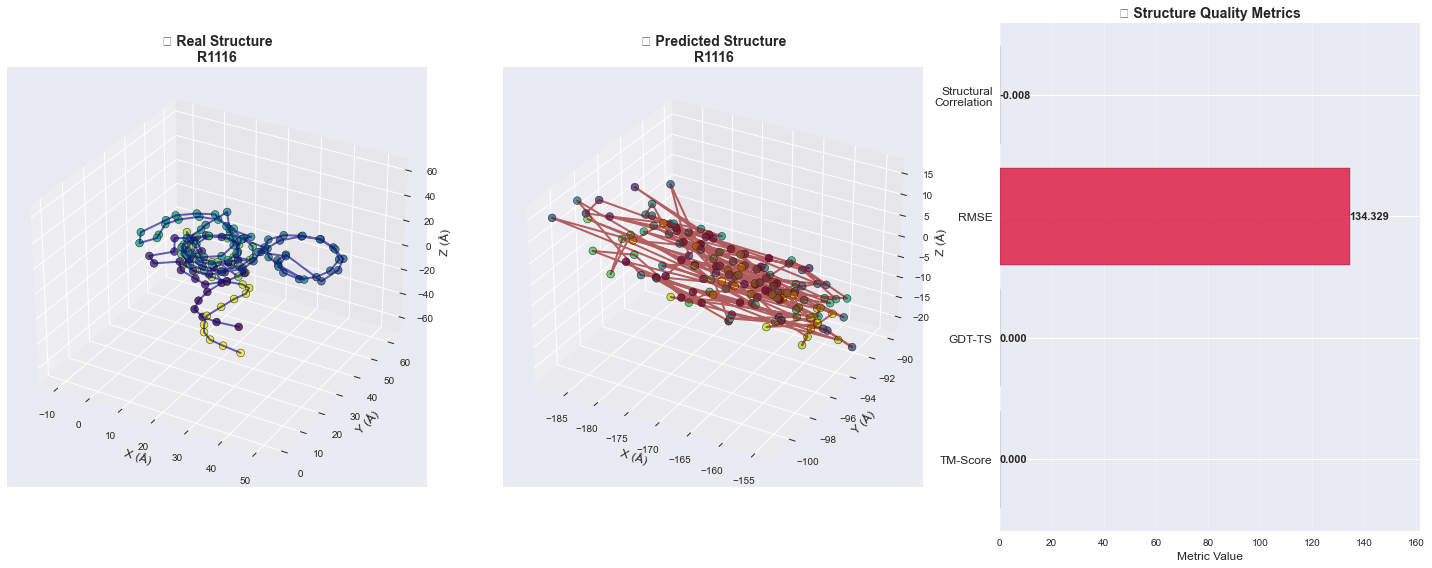


🔬 Analyzing sequence 2/5: R1149
📊 TM-Score: 0.000, GDT-TS: 0.000


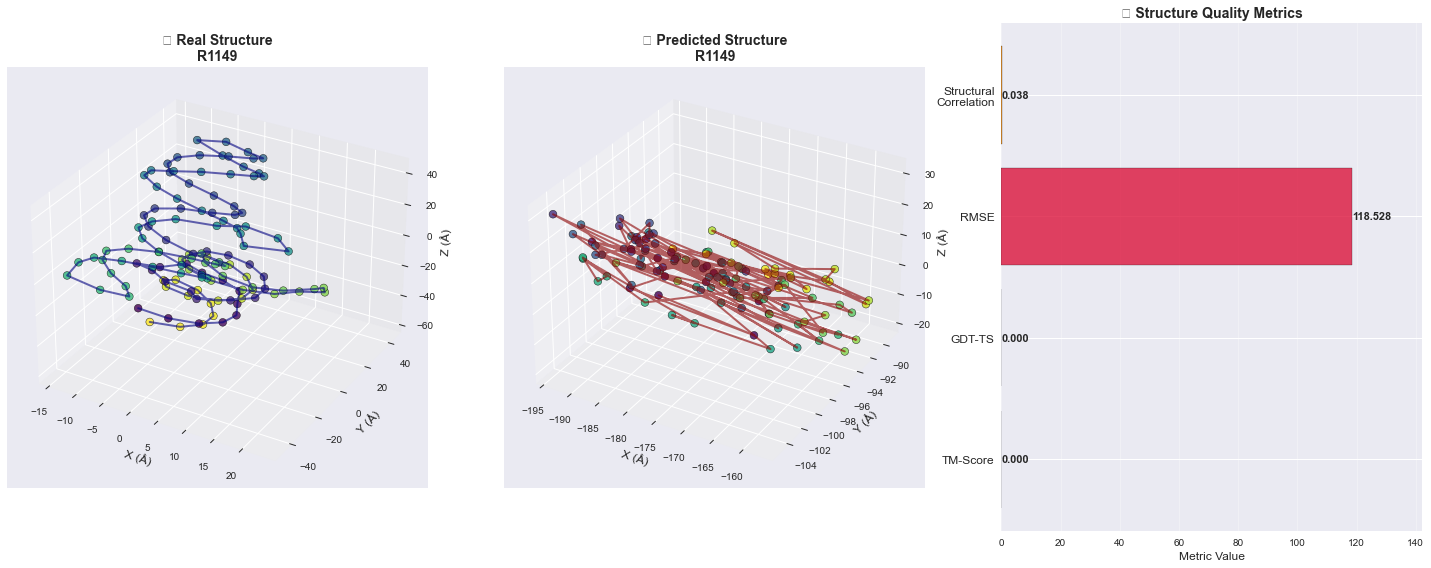


🔬 Analyzing sequence 3/5: R1189
📊 TM-Score: 0.000, GDT-TS: 0.000


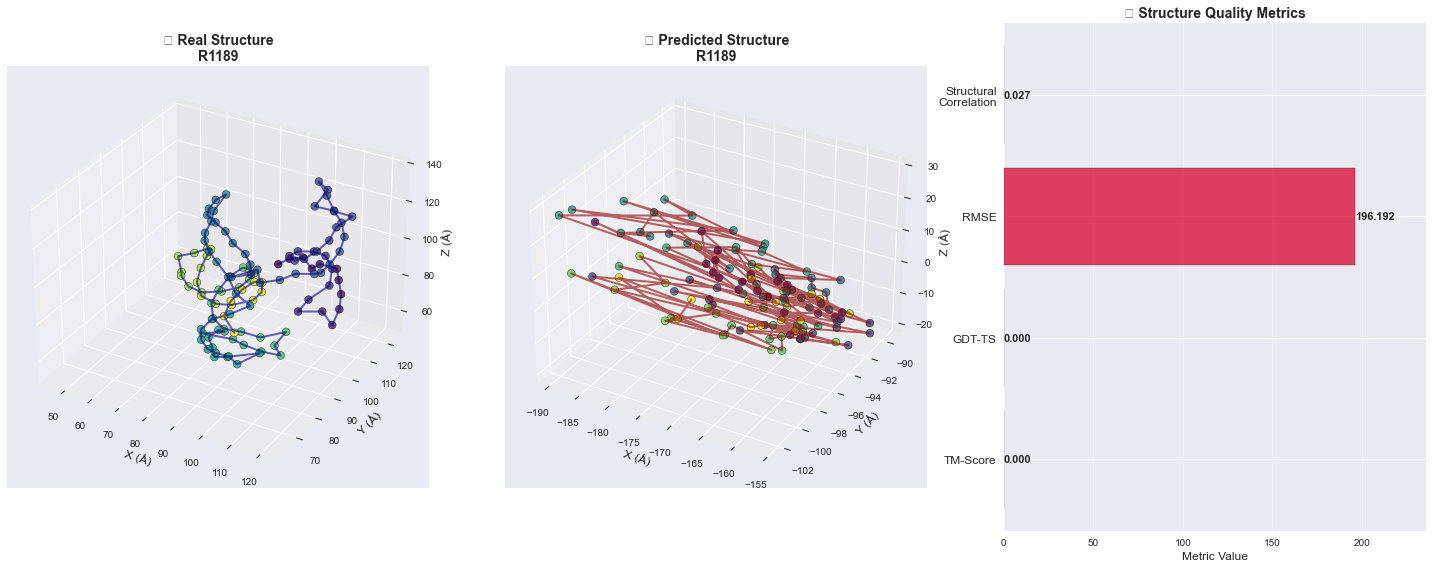


🔬 Analyzing sequence 4/5: R1138
📊 TM-Score: 0.000, GDT-TS: 0.000


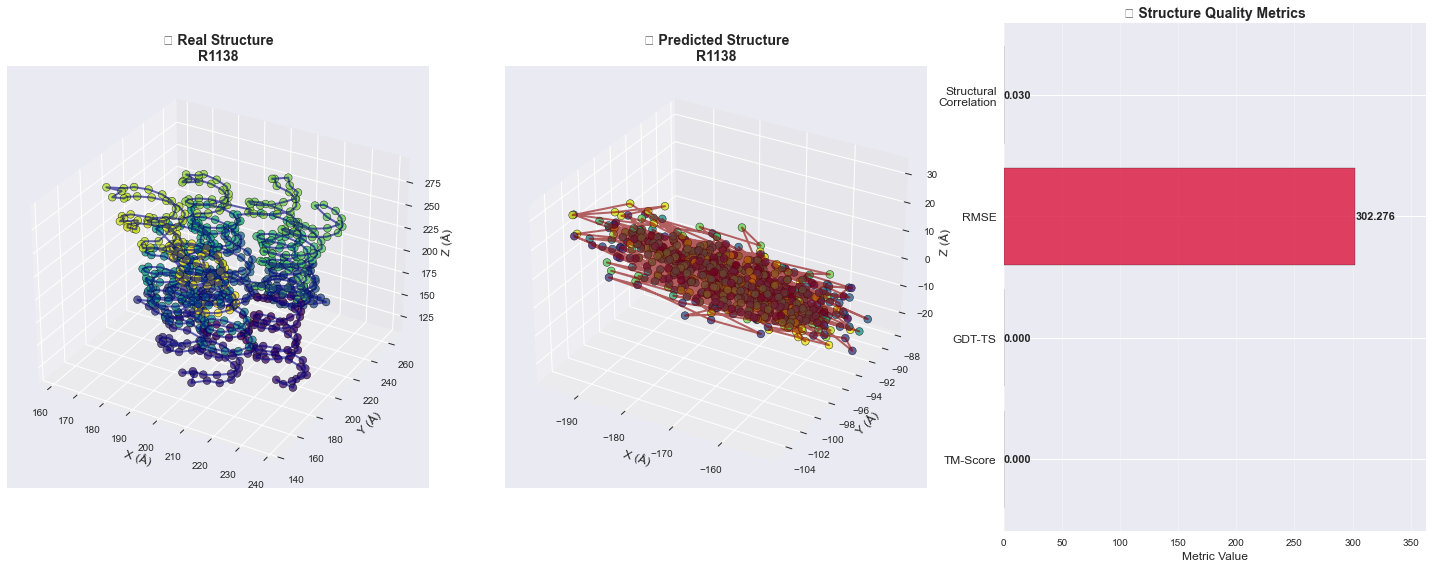


🔬 Analyzing sequence 5/5: R1156
📊 TM-Score: 0.000, GDT-TS: 0.000


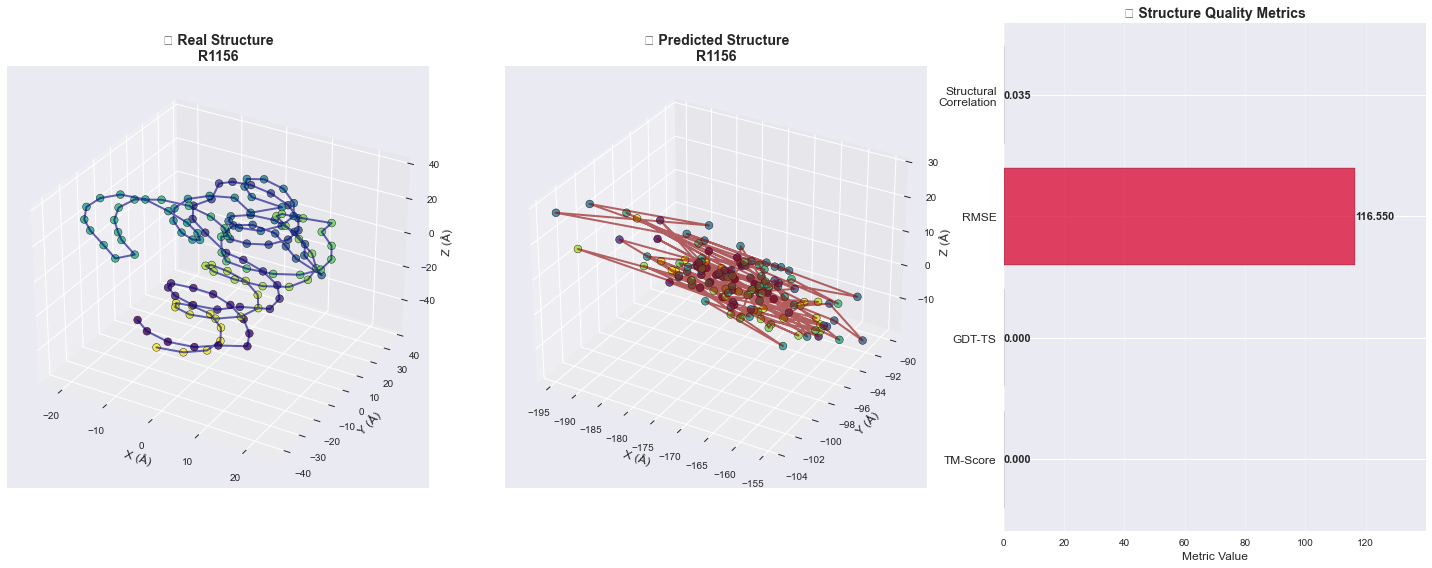


📈 Creating summary analysis for 5 sequences...
💾 Summary table saved to: ./unet4_rl2/structure_metrics_summary.csv

📊 SUMMARY STATISTICS
🎯 Average TM-Score: 0.0003 ± 0.0001
📏 Average GDT-TS: 0.0000 ± 0.0000
📐 Average RMSE: 173.5750 ± 78.8950


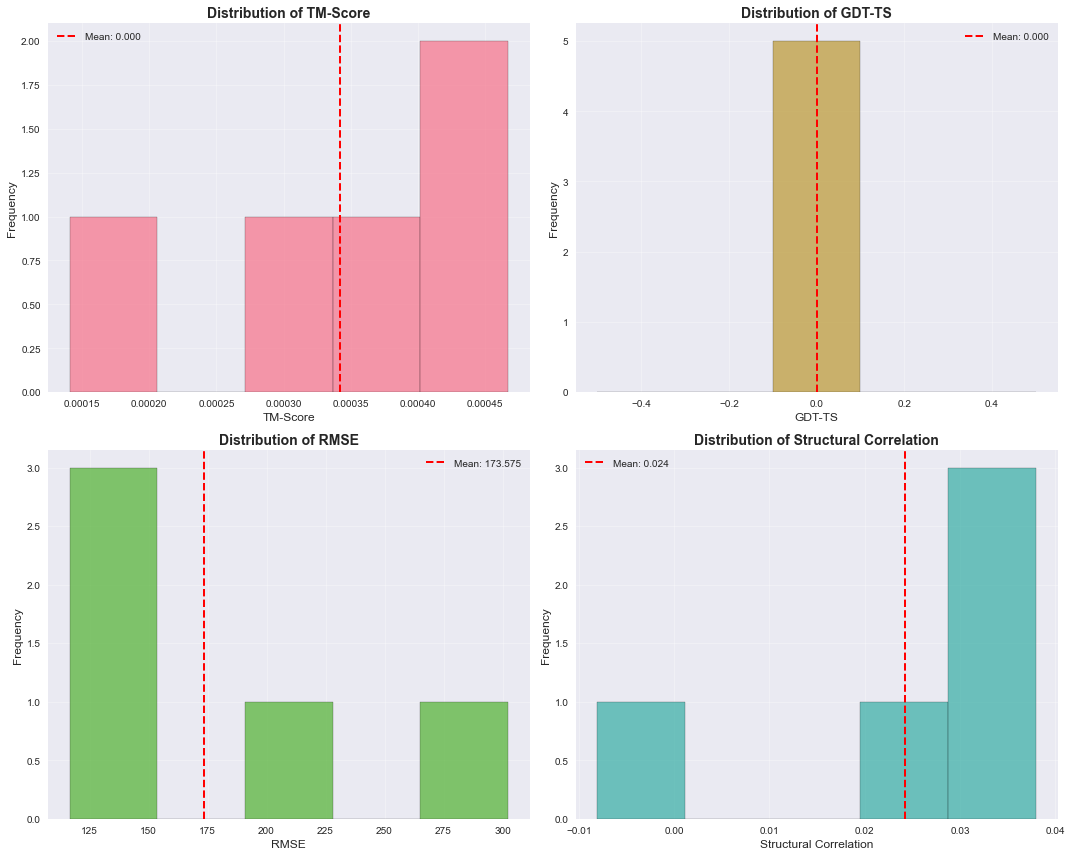


✅ Analysis complete! Check ./unet4_rl2 for all outputs.


In [22]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# File paths
DATA_DIR = "./data"
OUTPUT_DIR = "./unet4_rl2"

def load_submission_and_validation():
    """
    Load submission file and validation data for comparison.
    """
    # Load submission
    #submission_df = pd.read_csv(os.path.join(OUTPUT_DIR, "submission.csv"))
    df = pd.read_csv(os.path.join(OUTPUT_DIR, "sample_submission_predicted.csv"))
    df_renamed = df.rename(columns={"x_1": "x", "y_1": "y", "z_1": "z"})
    submission_df = df_renamed[["ID", "x", "y", "z"]]

    # Load validation data
    valid_seq = pd.read_csv(os.path.join(DATA_DIR, "validation_sequences.csv"))
    valid_labels = pd.read_csv(os.path.join(DATA_DIR, "validation_labels.csv"))
    
    return submission_df, valid_seq, valid_labels

def calculate_tm_score(coords1, coords2):
    """
    Calculate TM-score between two protein/RNA structures.
    
    TM-score is a measure of structural similarity ranging from 0 to 1,
    where 1 indicates identical structures.
    
    Parameters:
    -----------
    coords1, coords2 : numpy.ndarray
        3D coordinates of structures to compare
    
    Returns:
    --------
    tm_score : float
        TM-score between the two structures
    """
    # Ensure same length
    min_len = min(len(coords1), len(coords2))
    coords1 = coords1[:min_len]
    coords2 = coords2[:min_len]
    
    if min_len == 0:
        return 0.0
    
    # Calculate pairwise distances
    n = len(coords1)
    d0 = 1.24 * np.power(n - 15, 1/3) - 1.8  # Length-dependent cutoff
    d0 = max(d0, 0.5)  # Minimum cutoff
    
    # Calculate RMSD after optimal superposition
    # For simplicity, we'll use a simplified version without rotation optimization
    distances = np.linalg.norm(coords1 - coords2, axis=1)
    
    # TM-score calculation
    tm_score = np.sum(1 / (1 + (distances / d0)**2)) / n
    
    return tm_score

def calculate_gdt_ts(coords1, coords2):
    """
    Calculate GDT-TS (Global Distance Test - Total Score).
    
    Parameters:
    -----------
    coords1, coords2 : numpy.ndarray
        3D coordinates of structures to compare
    
    Returns:
    --------
    gdt_ts : float
        GDT-TS score
    """
    min_len = min(len(coords1), len(coords2))
    coords1 = coords1[:min_len]
    coords2 = coords2[:min_len]
    
    if min_len == 0:
        return 0.0
    
    distances = np.linalg.norm(coords1 - coords2, axis=1)
    
    # Calculate percentage of residues within different distance cutoffs
    cutoffs = [1.0, 2.0, 4.0, 8.0]  # Angstroms
    percentages = []
    
    for cutoff in cutoffs:
        within_cutoff = np.sum(distances <= cutoff) / len(distances) * 100
        percentages.append(within_cutoff)
    
    # GDT-TS is the average of percentages at all cutoffs
    gdt_ts = np.mean(percentages)
    
    return gdt_ts

def calculate_comprehensive_metrics(real_coords, pred_coords):
    """
    Calculate comprehensive structural comparison metrics.
    
    Parameters:
    -----------
    real_coords, pred_coords : numpy.ndarray
        Real and predicted 3D coordinates
    
    Returns:
    --------
    metrics : dict
        Dictionary containing various structural metrics
    """
    # Ensure same length
    min_len = min(len(real_coords), len(pred_coords))
    real_coords = real_coords[:min_len]
    pred_coords = pred_coords[:min_len]
    
    if min_len == 0:
        return {}
    
    # Basic metrics
    rmse = np.sqrt(mean_squared_error(real_coords.flatten(), pred_coords.flatten()))
    mae = mean_absolute_error(real_coords.flatten(), pred_coords.flatten())
    
    # Distance matrix comparison
    real_dist_matrix = np.linalg.norm(
        real_coords[:, np.newaxis] - real_coords, axis=2
    )
    pred_dist_matrix = np.linalg.norm(
        pred_coords[:, np.newaxis] - pred_coords, axis=2
    )
    
    # Distance MAE
    distance_mae = np.mean(np.abs(real_dist_matrix - pred_dist_matrix))
    
    # Structural correlation
    correlation = np.corrcoef(
        real_dist_matrix.flatten(),
        pred_dist_matrix.flatten()
    )[0, 1] if len(real_coords) > 1 else 0.0
    
    # Advanced metrics
    tm_score = calculate_tm_score(real_coords, pred_coords)
    gdt_ts = calculate_gdt_ts(real_coords, pred_coords)
    
    # Radius of gyration comparison
    real_centroid = np.mean(real_coords, axis=0)
    pred_centroid = np.mean(pred_coords, axis=0)
    
    real_rg = np.sqrt(np.mean(np.sum((real_coords - real_centroid)**2, axis=1)))
    pred_rg = np.sqrt(np.mean(np.sum((pred_coords - pred_centroid)**2, axis=1)))
    
    return {
        'RMSE': rmse,
        'MAE': mae,
        'Distance MAE': distance_mae,
        'Structural Correlation': correlation,
        'TM-Score': tm_score,
        'GDT-TS': gdt_ts,
        'Real Radius of Gyration': real_rg,
        'Predicted Radius of Gyration': pred_rg,
        'RG Difference': abs(real_rg - pred_rg)
    }

def visualize_rna_structure_comparison(real_coords, pred_coords, seq_id, metrics):
    """
    Create 3D visualization comparing real and predicted RNA structures.
    
    Parameters:
    -----------
    real_coords, pred_coords : numpy.ndarray
        Real and predicted coordinates
    seq_id : str
        Sequence identifier
    metrics : dict
        Calculated metrics for this structure
    """
    fig = plt.figure(figsize=(20, 8))
    
    # 3D structure comparison
    ax1 = fig.add_subplot(131, projection='3d')
    ax2 = fig.add_subplot(132, projection='3d')
    
    # Ensure same length
    min_len = min(len(real_coords), len(pred_coords))
    real_coords = real_coords[:min_len]
    pred_coords = pred_coords[:min_len]
    
    # Color map for residue positions
    colors = plt.cm.viridis(np.linspace(0, 1, len(real_coords)))
    
    # Plot real structure
    ax1.scatter(real_coords[:, 0], real_coords[:, 1], real_coords[:, 2],
                c=colors, s=60, alpha=0.8, edgecolors='black', linewidth=0.5)
    ax1.plot(real_coords[:, 0], real_coords[:, 1], real_coords[:, 2],
             color='navy', alpha=0.6, linewidth=2)
    ax1.set_title(f'🧬 Real Structure\n{seq_id}', fontsize=14, fontweight='bold')
    ax1.set_xlabel('X (Å)', fontsize=12)
    ax1.set_ylabel('Y (Å)', fontsize=12)
    ax1.set_zlabel('Z (Å)', fontsize=12)
    
    # Plot predicted structure
    ax2.scatter(pred_coords[:, 0], pred_coords[:, 1], pred_coords[:, 2],
                c=colors, s=60, alpha=0.8, edgecolors='black', linewidth=0.5)
    ax2.plot(pred_coords[:, 0], pred_coords[:, 1], pred_coords[:, 2],
             color='darkred', alpha=0.6, linewidth=2)
    ax2.set_title(f'🔮 Predicted Structure\n{seq_id}', fontsize=14, fontweight='bold')
    ax2.set_xlabel('X (Å)', fontsize=12)
    ax2.set_ylabel('Y (Å)', fontsize=12)
    ax2.set_zlabel('Z (Å)', fontsize=12)
    
    # Metrics visualization
    ax3 = fig.add_subplot(133)
    
    # Select key metrics for display
    key_metrics = {
        'TM-Score': metrics.get('TM-Score', 0),
        'GDT-TS': metrics.get('GDT-TS', 0),
        'RMSE': metrics.get('RMSE', 0),
        'Structural\nCorrelation': metrics.get('Structural Correlation', 0)
    }
    
    # Create horizontal bar chart
    y_pos = np.arange(len(key_metrics))
    values = list(key_metrics.values())
    colors_bar = ['#2E8B57', '#4682B4', '#DC143C', '#FF8C00']
    
    bars = ax3.barh(y_pos, values, color=colors_bar, alpha=0.8, edgecolor='black')
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels(key_metrics.keys(), fontsize=12)
    ax3.set_xlabel('Metric Value', fontsize=12)
    ax3.set_title('📊 Structure Quality Metrics', fontsize=14, fontweight='bold')
    
    # Add value labels on bars
    for i, (bar, value) in enumerate(zip(bars, values)):
        ax3.text(value + 0.01, bar.get_y() + bar.get_height()/2,
                f'{value:.3f}', va='center', fontsize=11, fontweight='bold')
    
    ax3.set_xlim(0, max(max(values) * 1.2, 1.0))
    ax3.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    return fig

def create_metrics_summary_table(all_metrics, sequence_ids):
    """
    Create a comprehensive summary table of all metrics.
    
    Parameters:
    -----------
    all_metrics : list
        List of metric dictionaries for each sequence
    sequence_ids : list
        List of sequence identifiers
    
    Returns:
    --------
    summary_df : pandas.DataFrame
        Summary dataframe with all metrics
    """
    summary_data = []
    
    for seq_id, metrics in zip(sequence_ids, all_metrics):
        if metrics:
            row = {'Sequence_ID': seq_id}
            row.update(metrics)
            summary_data.append(row)
    
    summary_df = pd.DataFrame(summary_data)
    
    # Calculate overall statistics
    if len(summary_df) > 0:
        numeric_cols = summary_df.select_dtypes(include=[np.number]).columns
        
        # Add summary rows
        mean_row = {'Sequence_ID': 'MEAN'}
        median_row = {'Sequence_ID': 'MEDIAN'}
        std_row = {'Sequence_ID': 'STD'}
        
        for col in numeric_cols:
            mean_row[col] = summary_df[col].mean()
            median_row[col] = summary_df[col].median()
            std_row[col] = summary_df[col].std()
        
        # Add summary rows to dataframe
        summary_rows = pd.DataFrame([mean_row, median_row, std_row])
        summary_df = pd.concat([summary_df, summary_rows], ignore_index=True)
    
    return summary_df

def plot_metrics_distribution(summary_df):
    """
    Create distribution plots for key metrics.
    
    Parameters:
    -----------
    summary_df : pandas.DataFrame
        Summary dataframe with metrics
    """
    # Filter out summary rows for distribution plots
    data_df = summary_df[~summary_df['Sequence_ID'].isin(['MEAN', 'MEDIAN', 'STD'])]
    
    if len(data_df) == 0:
        return
    
    # Select key metrics for distribution analysis
    key_metrics = ['TM-Score', 'GDT-TS', 'RMSE', 'Structural Correlation']
    available_metrics = [col for col in key_metrics if col in data_df.columns]
    
    if not available_metrics:
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    for i, metric in enumerate(available_metrics[:4]):
        if i < len(axes):
            ax = axes[i]
            
            # Histogram
            ax.hist(data_df[metric].dropna(), bins=min(20, len(data_df)), 
                   alpha=0.7, color=sns.color_palette("husl")[i], edgecolor='black')
            
            # Add mean line
            mean_val = data_df[metric].mean()
            ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                      label=f'Mean: {mean_val:.3f}')
            
            ax.set_title(f'Distribution of {metric}', fontsize=14, fontweight='bold')
            ax.set_xlabel(metric, fontsize=12)
            ax.set_ylabel('Frequency', fontsize=12)
            ax.legend()
            ax.grid(alpha=0.3)
    
    # Remove empty subplots
    for i in range(len(available_metrics), len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    return fig

def main():
    """
    Main function to run the complete visualization and analysis.
    """
    print("🧬 RNA Structure Prediction Analysis")
    print("=" * 50)
    
    # Load data
    print("📁 Loading submission and validation data...")
    try:
        submission_df, valid_seq, valid_labels = load_submission_and_validation()
        print(f"✅ Loaded {len(submission_df)} predictions and validation data")
    except Exception as e:
        print(f"❌ Error loading data: {e}")
        return
    
    # Create validation mapping
    print("\n🔗 Creating validation data mapping...")
    valid_labels['seq_id'] = valid_labels['ID'].apply(lambda x: x.split('_')[0])
    
    # Get unique sequence IDs from validation
    valid_seq_ids = set(valid_seq['target_id'])
    label_seq_ids = set(valid_labels['seq_id'])
    common_seq_ids = list(valid_seq_ids.intersection(label_seq_ids))
    
    print(f"✅ Found {len(common_seq_ids)} sequences for comparison")
    
    if not common_seq_ids:
        print("❌ No common sequences found between validation and labels")
        return
    
    # Analyze each sequence
    all_metrics = []
    sequence_ids = []
    
    for i, seq_id in enumerate(common_seq_ids[:5]):  # Limit to first 5 for demo
        print(f"\n🔬 Analyzing sequence {i+1}/{min(5, len(common_seq_ids))}: {seq_id}")
        
        try:
            # Get real coordinates
            seq_labels = valid_labels[valid_labels['seq_id'] == seq_id].sort_values('resid')
            
            # Find available structures
            structure_cols = [col for col in seq_labels.columns if col.startswith('x_')]
            if not structure_cols:
                print(f"⚠️  No structure data found for {seq_id}")
                continue
            
            # Use first structure
            struct_num = structure_cols[0].split('_')[1]
            
            real_coords = []
            for _, row in seq_labels.iterrows():
                x = row[f'x_{struct_num}']
                y = row[f'y_{struct_num}']
                z = row[f'z_{struct_num}']
                
                if abs(x) < 1e15 and abs(y) < 1e15 and abs(z) < 1e15:
                    real_coords.append([x, y, z])
                else:
                    real_coords.append([np.nan, np.nan, np.nan])
            
            real_coords = np.array(real_coords)
            
            # Get predicted coordinates
            pred_data = []
            for j in range(len(real_coords)):
                pred_id = f"{seq_id}_{j+1}"
                if pred_id in submission_df['ID'].values:
                    row = submission_df[submission_df['ID'] == pred_id].iloc[0]
                    pred_data.append([row['x'], row['y'], row['z']])
                else:
                    pred_data.append([0.0, 0.0, 0.0])
            
            pred_coords = np.array(pred_data)
            
            # Remove NaN coordinates
            valid_mask = ~np.isnan(real_coords).any(axis=1)
            real_coords_clean = real_coords[valid_mask]
            pred_coords_clean = pred_coords[valid_mask]
            
            if len(real_coords_clean) == 0:
                print(f"⚠️  No valid coordinates for {seq_id}")
                continue
            
            # Calculate metrics
            metrics = calculate_comprehensive_metrics(real_coords_clean, pred_coords_clean)
            all_metrics.append(metrics)
            sequence_ids.append(seq_id)
            
            print(f"📊 TM-Score: {metrics['TM-Score']:.3f}, GDT-TS: {metrics['GDT-TS']:.3f}")
            
            # Create visualization
            fig = visualize_rna_structure_comparison(
                real_coords_clean, pred_coords_clean, seq_id, metrics
            )
            
            # Save figure
            fig_path = os.path.join(OUTPUT_DIR, f'structure_comparison_{seq_id}.png')
            fig.savefig(fig_path, dpi=300, bbox_inches='tight')
            plt.show()
            
        except Exception as e:
            print(f"❌ Error processing {seq_id}: {e}")
            continue
    
    # Create summary analysis
    if all_metrics:
        print(f"\n📈 Creating summary analysis for {len(all_metrics)} sequences...")
        
        # Create summary table
        summary_df = create_metrics_summary_table(all_metrics, sequence_ids)
        
        # Save summary table
        summary_path = os.path.join(OUTPUT_DIR, 'structure_metrics_summary.csv')
        summary_df.to_csv(summary_path, index=False)
        print(f"💾 Summary table saved to: {summary_path}")
        
        # Display summary statistics
        print("\n📊 SUMMARY STATISTICS")
        print("=" * 30)
        
        if 'TM-Score' in summary_df.columns:
            tm_mean = summary_df[summary_df['Sequence_ID'] == 'MEAN']['TM-Score'].iloc[0]
            tm_std = summary_df[summary_df['Sequence_ID'] == 'STD']['TM-Score'].iloc[0]
            print(f"🎯 Average TM-Score: {tm_mean:.4f} ± {tm_std:.4f}")
        
        if 'GDT-TS' in summary_df.columns:
            gdt_mean = summary_df[summary_df['Sequence_ID'] == 'MEAN']['GDT-TS'].iloc[0]
            gdt_std = summary_df[summary_df['Sequence_ID'] == 'STD']['GDT-TS'].iloc[0]
            print(f"📏 Average GDT-TS: {gdt_mean:.4f} ± {gdt_std:.4f}")
        
        if 'RMSE' in summary_df.columns:
            rmse_mean = summary_df[summary_df['Sequence_ID'] == 'MEAN']['RMSE'].iloc[0]
            rmse_std = summary_df[summary_df['Sequence_ID'] == 'STD']['RMSE'].iloc[0]
            print(f"📐 Average RMSE: {rmse_mean:.4f} ± {rmse_std:.4f}")
        
        # Create distribution plots
        dist_fig = plot_metrics_distribution(summary_df)
        if dist_fig:
            dist_path = os.path.join(OUTPUT_DIR, 'metrics_distribution.png')
            dist_fig.savefig(dist_path, dpi=300, bbox_inches='tight')
            plt.show()
        
        print(f"\n✅ Analysis complete! Check {OUTPUT_DIR} for all outputs.")
    
    else:
        print("❌ No valid sequences could be analyzed.")

if __name__ == "__main__":
    main()